In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon

In [3]:
import numpy as np
from scipy.sparse import issparse

# Data

In [17]:
# Info
whatFer = "one" # "one" or  "two"

#Load data
#So .X is log1p(CP1e6) (CPM-style per-million normalization, then log1p)
base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
adata_file  = base_folder / "adata_mac_annotated.h5ad"
lr_results  = base_folder / "lr_all_results.h5ad"


adata = sc.read_h5ad(adata_file)
lr_all = sc.read_h5ad(lr_results)

# Processing lr_all data

## appending spp1|cd44

In [18]:
## import re
import numpy as np
import pandas as pd
from scipy import sparse

# --- find the Spp1|Cd44 interaction column in lr_all ---
lig_col = 'ligand' if 'ligand' in lr_all.var.columns else None
rec_col = 'receptor' if 'receptor' in lr_all.var.columns else None

hits = []
if lig_col and rec_col:
    mask = (lr_all.var[lig_col].str.lower() == 'spp1') & (lr_all.var[rec_col].str.lower() == 'cd44')
    hits = lr_all.var_names[mask].tolist()
if not hits:
    pat = re.compile(r'^spp1\|cd44$', flags=re.IGNORECASE)
    hits = [v for v in lr_all.var_names if pat.match(v)]
assert len(hits) >= 1, "Spp1|Cd44 interaction not found in lr_all.var/var_names"
i_name = hits[0]
j = list(lr_all.var_names).index(i_name)
print(f"Using interaction: {i_name} @ column {j}")

# --- pull local scores from lr_all and map onto adata.obs_names ---
xcol = lr_all.X[:, j].toarray().ravel() if sparse.issparse(lr_all.X) else np.asarray(lr_all.X).ravel()[::lr_all.n_vars*0+1]  # safe 1D
scores = pd.Series(xcol, index=lr_all.obs_names, name="LR_Spp1_Cd44")

# align to adata (missing cells -> NaN)
adata.obs["LR_Spp1_Cd44"] = scores.reindex(adata.obs_names).values
adata.obs["LR_Spp1_Cd44"].head()


Using interaction: Spp1^Cd44 @ column 145


ID_100000    0.000000
ID_100001    0.000000
ID_100005    0.000000
ID_100006    0.000000
ID_100007    0.101806
Name: LR_Spp1_Cd44, dtype: float32

## Defining spp1 high and high lr macrophages

In [20]:
# Parameters
quantile = 0.80      # top 20% within each mouse among *Spp1+ macrophages*
prefix = ""          # set if you used write_prefix in your mac annotation

mac_col  = f"{prefix}Mac_like_tiered"   # 1/0 from mac_call.annotate_macrophage_polarization
spp1_col = f"{prefix}Spp1_pos"          # 1/0
mouse_key = "mouse"

# sanity
for c in (mac_col, spp1_col, "LR_Spp1_Cd44", mouse_key):
    assert c in adata.obs.columns, f"Missing {c}"

In [21]:
obs = adata.obs[[mac_col, spp1_col, "LR_Spp1_Cd44", mouse_key]].copy()
obs["is_mac"] = obs[mac_col].astype(bool).values
obs["is_spp1pos"] = obs[spp1_col].astype(int).values == 1

# compute per-mouse LR threshold using only Spp1+ macrophages
thr = {}
for m, dfm in obs.groupby(mouse_key):
    sel = dfm["is_mac"] & dfm["is_spp1pos"] & np.isfinite(dfm["LR_Spp1_Cd44"])
    if sel.any():
        thr[m] = dfm.loc[sel, "LR_Spp1_Cd44"].quantile(quantile)
    else:
        thr[m] = np.nan

# mark high LR (>= mouse-specific threshold) among Spp1+ macrophages
def is_high(row):
    t = thr.get(row[mouse_key], np.nan)
    return (row["is_mac"] and row["is_spp1pos"] and np.isfinite(row["LR_Spp1_Cd44"]) and np.isfinite(t) and (row["LR_Spp1_Cd44"] >= t))

adata.obs["Mac_Spp1pos_highLR"] = obs.apply(is_high, axis=1).astype(int)

# also define Spp1-negative macrophages
adata.obs["Mac_Spp1neg"] = ((obs["is_mac"]) & (~obs["is_spp1pos"])).astype(int)

print("Counts:")
print("  Mac_Spp1pos_highLR =", int(adata.obs["Mac_Spp1pos_highLR"].sum()))
print("  Mac_Spp1neg        =", int(adata.obs["Mac_Spp1neg"].sum()))

/tmp/ipykernel_2376/1719567538.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Counts:
  Mac_Spp1pos_highLR = 3115
  Mac_Spp1neg        = 4623


## Sanity Check

In [23]:
import pandas as pd
import numpy as np

mouse_key = "mouse"  # change if your column is named differently

assert {"Mac_Spp1pos_highLR","Mac_Spp1neg"}.issubset(adata.obs.columns)
cnts = (adata.obs
        .assign(is_mac=lambda d: d[mac_col].astype(bool))
        .query("is_mac")
        .groupby(mouse_key)[["Mac_Spp1pos_highLR","Mac_Spp1neg"]]
        .sum()
        .astype(int)
        .rename(columns={"Mac_Spp1pos_highLR":"n_posHighLR", "Mac_Spp1neg":"n_neg"}))
display(cnts)


/tmp/ipykernel_2376/351891363.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,n_posHighLR,n_neg
mouse,,
CyPSCA_1_1,730,1158
CyPSCA_1_2,922,714
CyT72_1_4,68,321
NoTx_2_2,97,33
RTCyPSCA_1_4,267,868
RTCyPSCA_2_4,617,851
RTCyT72_2_1,67,198
RTCyT72_2_4,347,480


# DE Spp1-cd44 high vs Spp1 neg Macs

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc

# Your target folder
outdir = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/spp1.cd44.high.analysis")
outdir.mkdir(parents=True, exist_ok=True)

# Group label used for DE (only macrophages, only the two groups)
adata.obs["mac_lr_grp"] = "other"
adata.obs.loc[(adata.obs["Mac_Spp1pos_highLR"]==1), "mac_lr_grp"] = "Spp1pos_highLR"
adata.obs.loc[(adata.obs["Mac_Spp1neg"]==1),       "mac_lr_grp"] = "Spp1neg"

# Quick counts per mouse
cnt = (adata.obs
       .query("mac_lr_grp != 'other'")
       .groupby(["mouse","mac_lr_grp"])
       .size().unstack(fill_value=0))
display(cnt.head())
print("Mice included:", cnt.index.tolist())


/tmp/ipykernel_2376/1631268532.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


mac_lr_grp,Spp1neg,Spp1pos_highLR
mouse,,
CyPSCA_1_1,1158,730
CyPSCA_1_2,714,922
CyT72_1_4,321,68
NoTx_2_2,33,97
RTCyPSCA_1_4,868,267


Mice included: ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyT72_1_4', 'NoTx_2_2', 'RTCyPSCA_1_4', 'RTCyPSCA_2_4', 'RTCyT72_2_1', 'RTCyT72_2_4']


## DE - single-cell Wilcoxon

In [28]:
import numpy as np
import pandas as pd
import scanpy as sc

# Minimum cells per group to run DE
MIN_CELLS = 25

def _rg_to_df(ad, group="Spp1pos_highLR"):
    rg = ad.uns["rank_genes_groups"]
    k = group
    return pd.DataFrame({
        "gene": rg["names"][k],
        "log2FC": rg["logfoldchanges"][k],
        "pval": rg["pvals"][k],
        "padj": rg["pvals_adj"][k],
        "scores": rg["scores"][k],
        "pct_in_group": rg["pts"][k] if "pts" in rg else np.nan,
        "pct_ref"     : rg["pts_rest"][k] if "pts_rest" in rg else np.nan
    })

mouse_list = cnt.index.tolist()
de_summaries = []

for m in mouse_list:
    sub = adata[(adata.obs["mouse"]==m) & (adata.obs["mac_lr_grp"].isin(["Spp1pos_highLR","Spp1neg"]))].copy()
    n_up   = int((sub.obs["mac_lr_grp"]=="Spp1pos_highLR").sum())
    n_down = int((sub.obs["mac_lr_grp"]=="Spp1neg").sum())
    if (n_up < MIN_CELLS) or (n_down < MIN_CELLS):
        print(f"[{m}] skipped (cells: {n_up} vs {n_down})")
        continue

    # Light gene filtering (expressed in >= 5 cells total)
    sc.pp.filter_genes(sub, min_cells=5)

    # Ensure we have log-normalized values for DE (uses .X or .raw)
    # If you already have, comment the next two lines:
    # sc.pp.normalize_total(sub, target_sum=1e4)
    # sc.pp.log1p(sub)

    # DE: Spp1pos_highLR vs Spp1neg
    sc.tl.rank_genes_groups(
        sub, groupby="mac_lr_grp",
        groups=["Spp1pos_highLR"], reference="Spp1neg",
        method="wilcoxon", corr_method="benjamini-hochberg",
        tie_correct=True, n_genes=sub.n_vars
    )
    df = _rg_to_df(sub, group="Spp1pos_highLR")
    df.insert(0, "mouse", m)

    # Save full table
    mout = outdir / f"{m}__DE_Spp1posHighLR_vs_Spp1neg.csv"
    df.to_csv(mout, index=False)
    print(f"[{m}] DE rows: {df.shape[0]} -> {mout.name}")

    # keep a tiny summary
    n_sig = int((df["padj"] < 0.05).sum())
    de_summaries.append({"mouse": m, "cells_up": n_up, "cells_neg": n_down, "genes_sig_padj<0.05": n_sig})

display(pd.DataFrame(de_summaries).sort_values("mouse"))


... storing 'mac_lr_grp' as categorical


[CyPSCA_1_1] DE rows: 10361 -> CyPSCA_1_1__DE_Spp1posHighLR_vs_Spp1neg.csv


... storing 'mac_lr_grp' as categorical


[CyPSCA_1_2] DE rows: 10854 -> CyPSCA_1_2__DE_Spp1posHighLR_vs_Spp1neg.csv


... storing 'mac_lr_grp' as categorical


...

... storing 'mac_lr_grp' as categorical


[RTCyT72_2_1] DE rows: 5344 -> RTCyT72_2_1__DE_Spp1posHighLR_vs_Spp1neg.csv


... storing 'mac_lr_grp' as categorical


[RTCyT72_2_4] DE rows: 9667 -> RTCyT72_2_4__DE_Spp1posHighLR_vs_Spp1neg.csv


,mouse,cells_up,cells_neg,genes_sig_padj<0.05
0,CyPSCA_1_1,730,1158,7493
1,CyPSCA_1_2,922,714,8411
2,CyT72_1_4,68,321,3250
3,NoTx_2_2,97,33,2
4,RTCyPSCA_1_4,267,868,7600
5,RTCyPSCA_2_4,617,851,8753
6,RTCyT72_2_1,67,198,3076
7,RTCyT72_2_4,347,480,6666


## Enrichment per mouse

In [43]:
import re, gseapy as gp
import pandas as pd

def pick_latest_with_mouse_pref(names, base_prefix, mouse_hint="mouse"):
    """
    Prefer Mouse-specific libraries (name contains 'mouse' case-insensitive),
    otherwise fall back to species-neutral version. Return the latest by year suffix.
    """
    names = pd.Index(map(str, names))  # ensure all entries are strings
    # candidate patterns: prefix..._20XX[_Mouse]? or prefix..._Mouse_20XX
    year_pat = re.compile(r"(?:_|\b)(20\d{2})(?:_|\b)", flags=re.I)

    def _latest(cands):
        items = []
        for n in cands:
            m = year_pat.search(n)
            if m:
                items.append((n, int(m.group(1))))
        if not items:
            return None
        return max(items, key=lambda x: x[1])[0]

    # strict prefix filter (case-insensitive)
    low_pref = base_prefix.lower()
    pref_mask = names.str.lower().str.startswith(low_pref)
    pref = names[pref_mask].tolist()

    # among those, prefer ones that mention mouse
    mouse = [n for n in pref if mouse_hint.lower() in n.lower()]
    if mouse:
        pick = _latest(mouse) or (mouse[0] if mouse else None)
        if pick:
            return pick, {"scope":"mouse", "cands":mouse}
    # else fallback to any species-neutral candidate
    pick = _latest(pref) or (pref[0] if pref else None)
    return pick, {"scope":"neutral", "cands":pref}

# get full list (some servers ignore organism filter)
all_libs = gp.get_library_name()                # all
mouse_libs = gp.get_library_name(organism="Mouse")  # try mouse filter too
libs = sorted(set(all_libs) | set(mouse_libs))

go_bp, go_meta         = pick_latest_with_mouse_pref(libs, "GO_Biological_Process")
reactome, rxn_meta     = pick_latest_with_mouse_pref(libs, "Reactome")
kegg, kegg_meta        = pick_latest_with_mouse_pref(libs, "KEGG")
wikipw, wp_meta        = pick_latest_with_mouse_pref(libs, "WikiPathways")  # optional

ENR_LIBS = [x for x in [go_bp, reactome, kegg, wikipw] if x]

print("Using libraries:", ENR_LIBS)
print("Details:")
for name, meta in [("GO_BP", go_meta), ("Reactome", rxn_meta), ("KEGG", kegg_meta), ("WikiPathways", wp_meta)]:
    if meta["cands"]:
        print(f"  {name}: picked from ({meta['scope']}), examples: {meta['cands'][:5]}")
    else:
        print(f"  {name}: none found")


Using libraries: ['GO_Biological_Process_2025', 'Reactome_Pathways_2024', 'KEGG_2019_Mouse', 'WikiPathways_2024_Mouse']
Details:
  GO_BP: picked from (neutral), examples: ['GO_Biological_Process_2021', 'GO_Biological_Process_2023', 'GO_Biological_Process_2025']
  Reactome: picked from (neutral), examples: ['Reactome_2022', 'Reactome_Pathways_2024']
  KEGG: picked from (mouse), examples: ['KEGG_2019_Mouse']
  WikiPathways: picked from (mouse), examples: ['WikiPathways_2019_Mouse', 'WikiPathways_2024_Mouse']


running CyPSCA_1_1


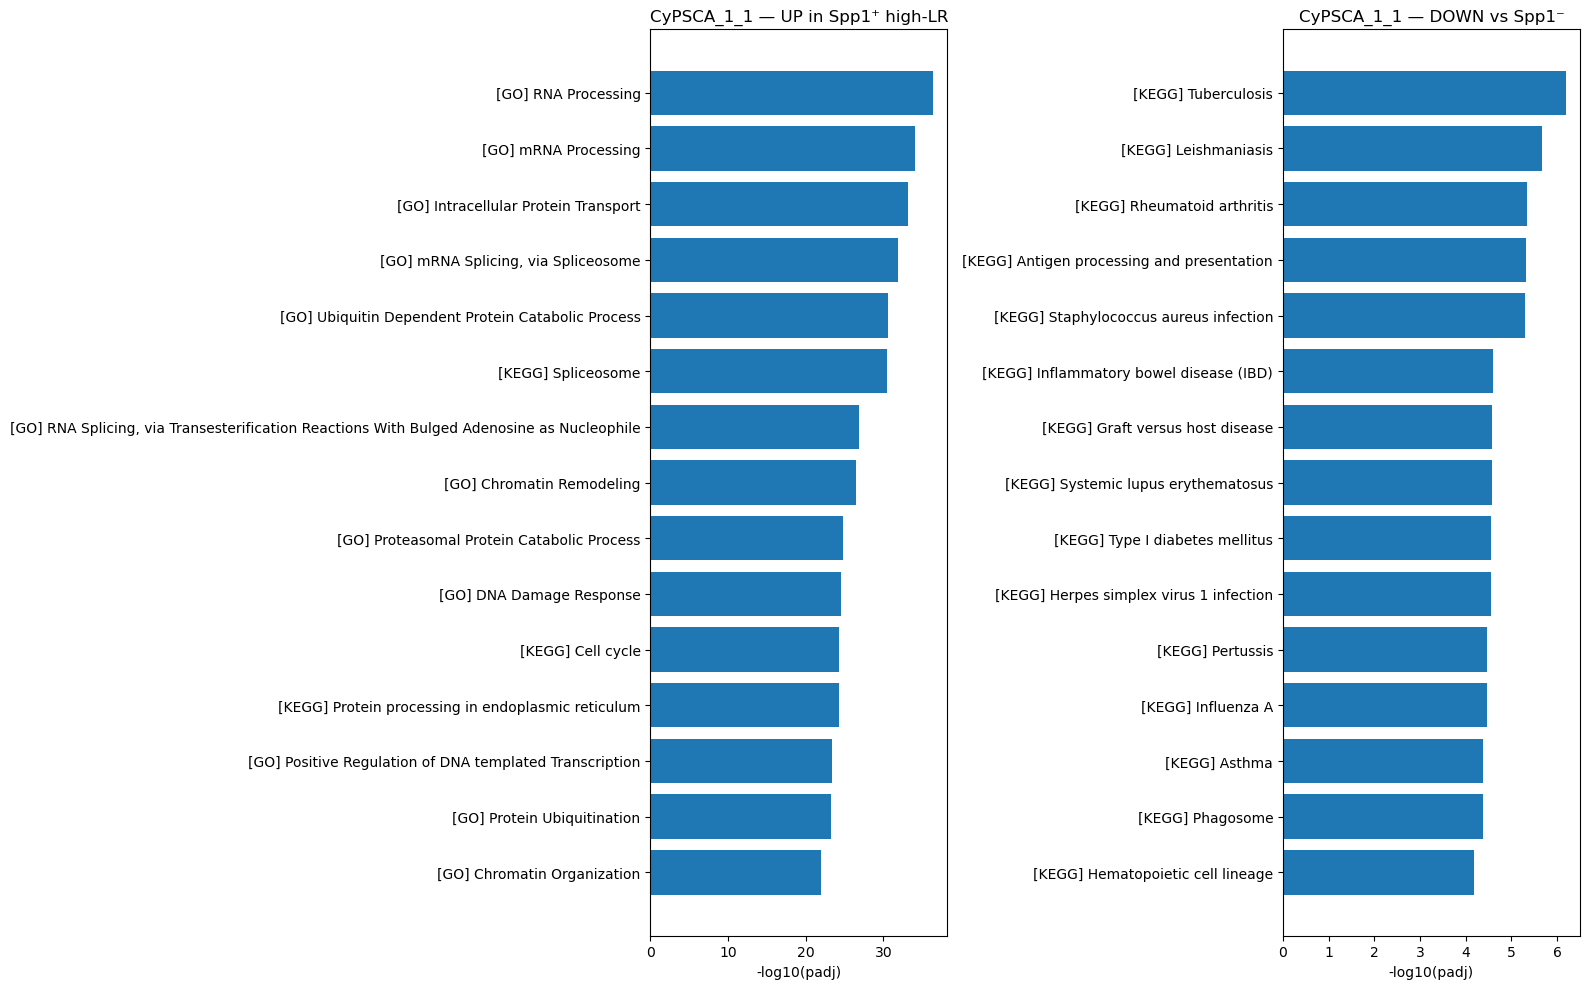

[CyPSCA_1_1] Saved combined enrichment figure -> CyPSCA_1_1__ENR_top15_up_and_down.png
running CyPSCA_1_2


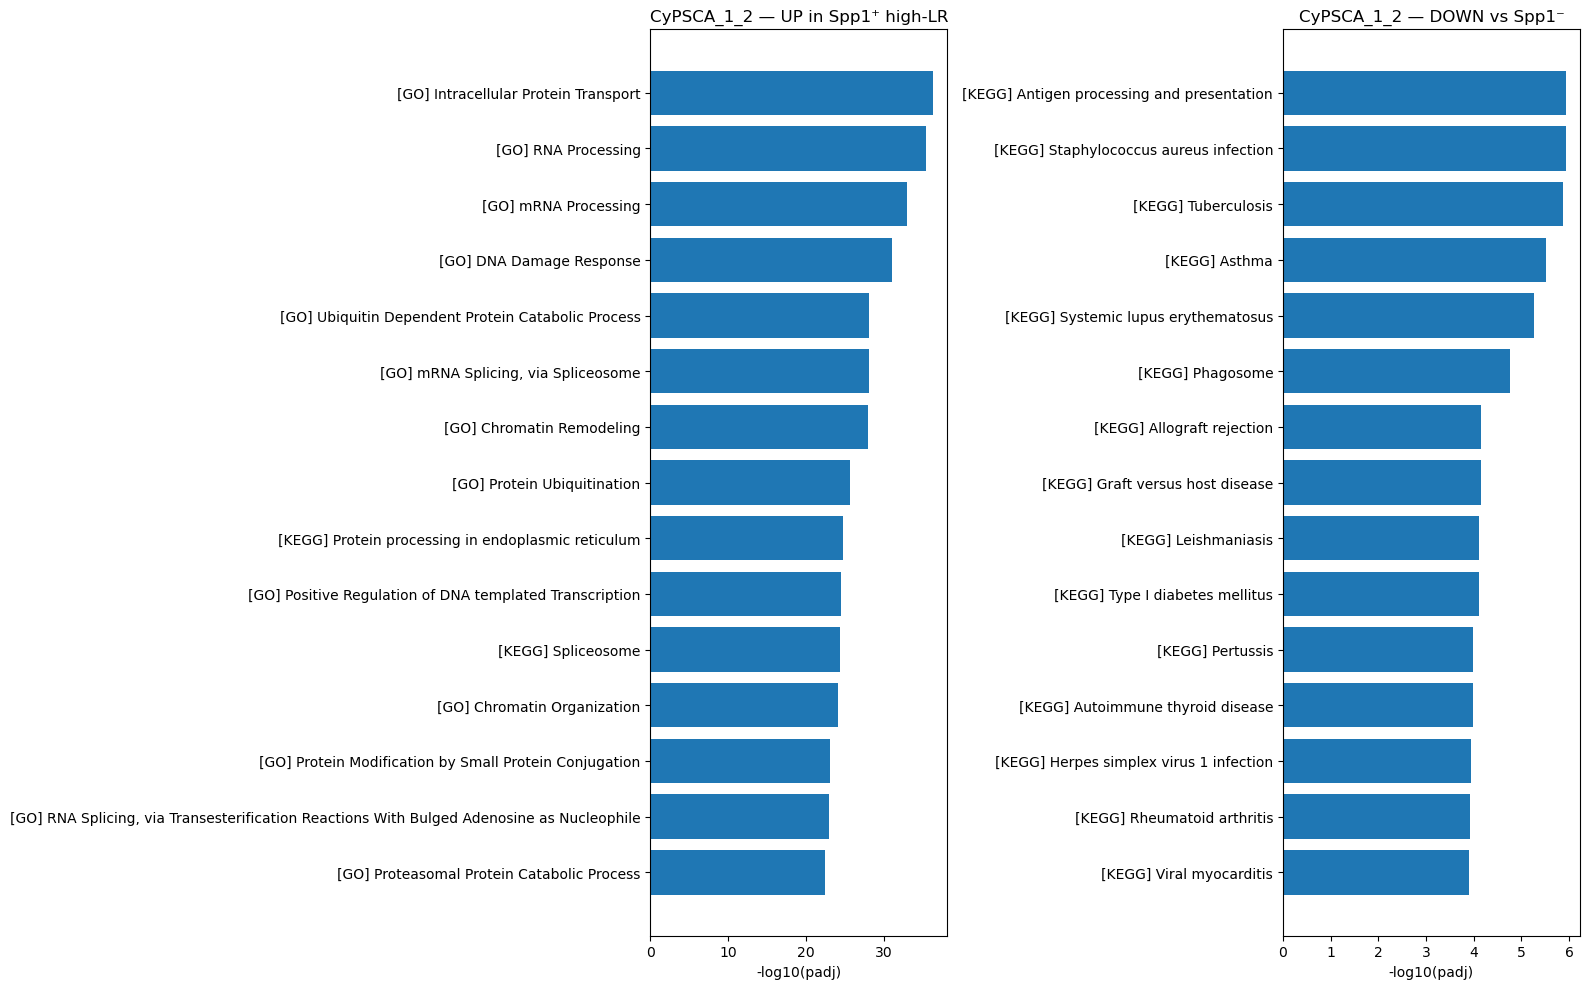

[CyPSCA_1_2] Saved combined enrichment figure -> CyPSCA_1_2__ENR_top15_up_and_down.png
running CyT72_1_4


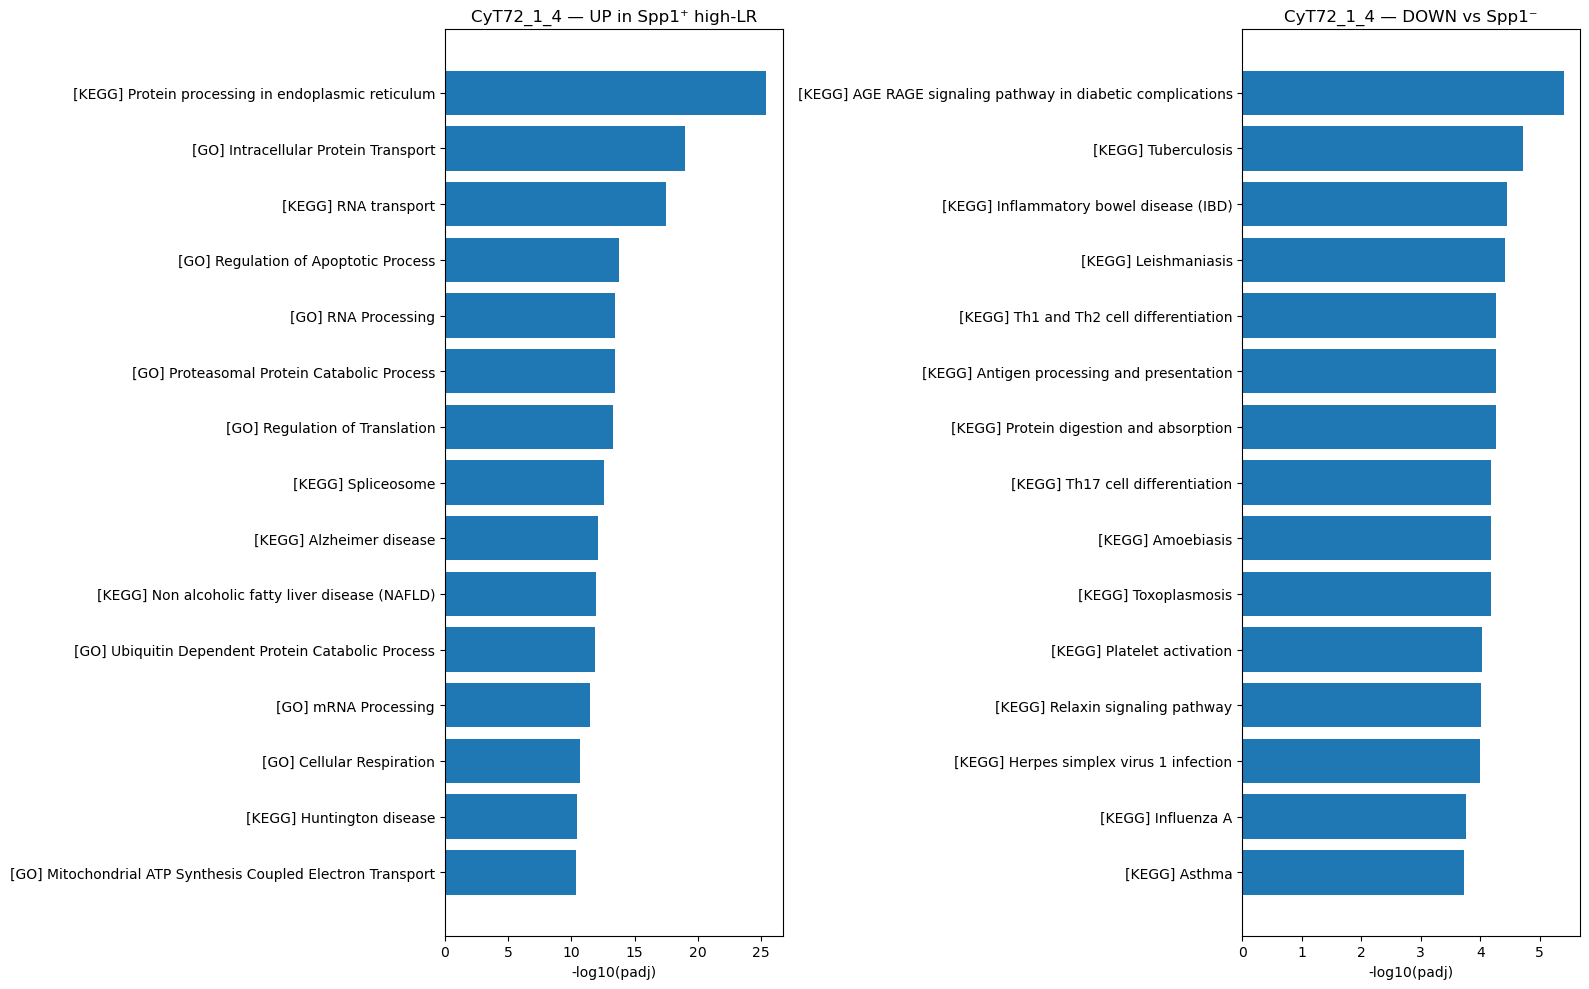

[CyT72_1_4] Saved combined enrichment figure -> CyT72_1_4__ENR_top15_up_and_down.png
running NoTx_2_2


/tmp/ipykernel_2376/3561018380.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


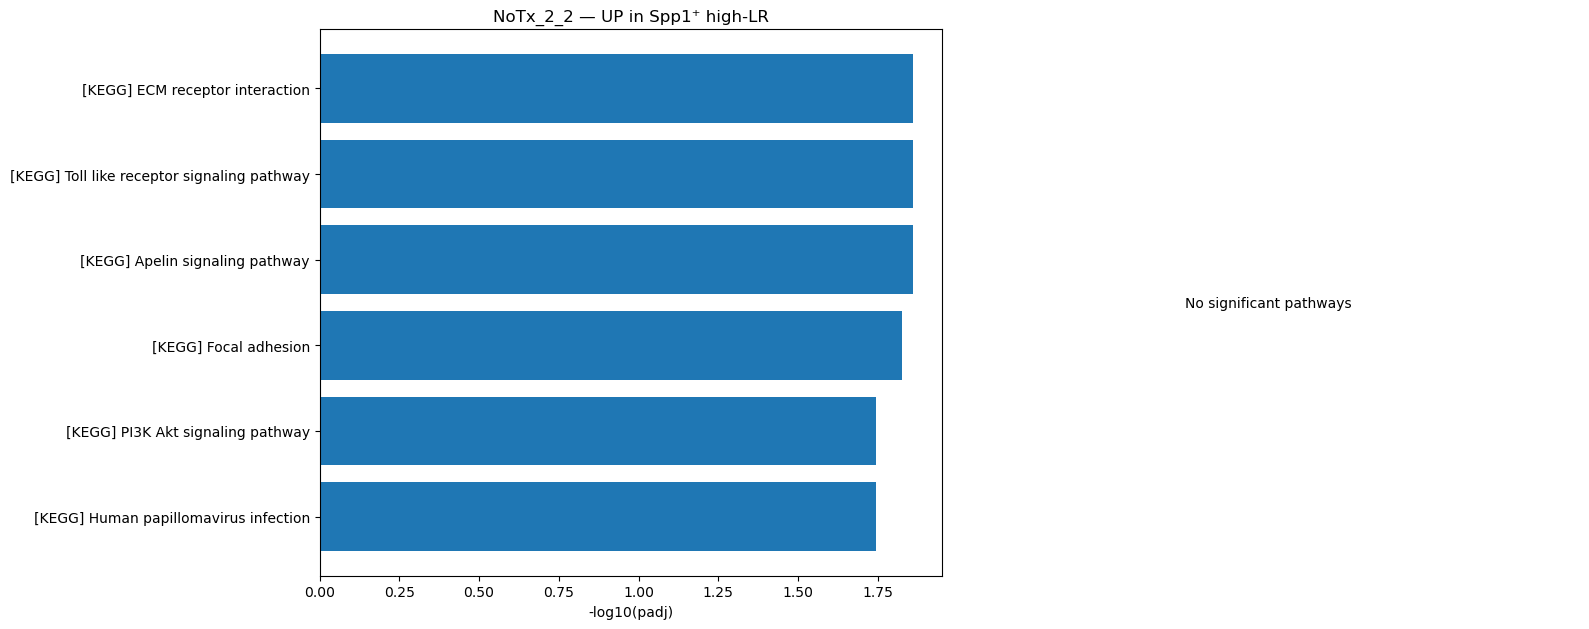

[NoTx_2_2] Saved combined enrichment figure -> NoTx_2_2__ENR_top15_up_and_down.png
running RTCyPSCA_1_4


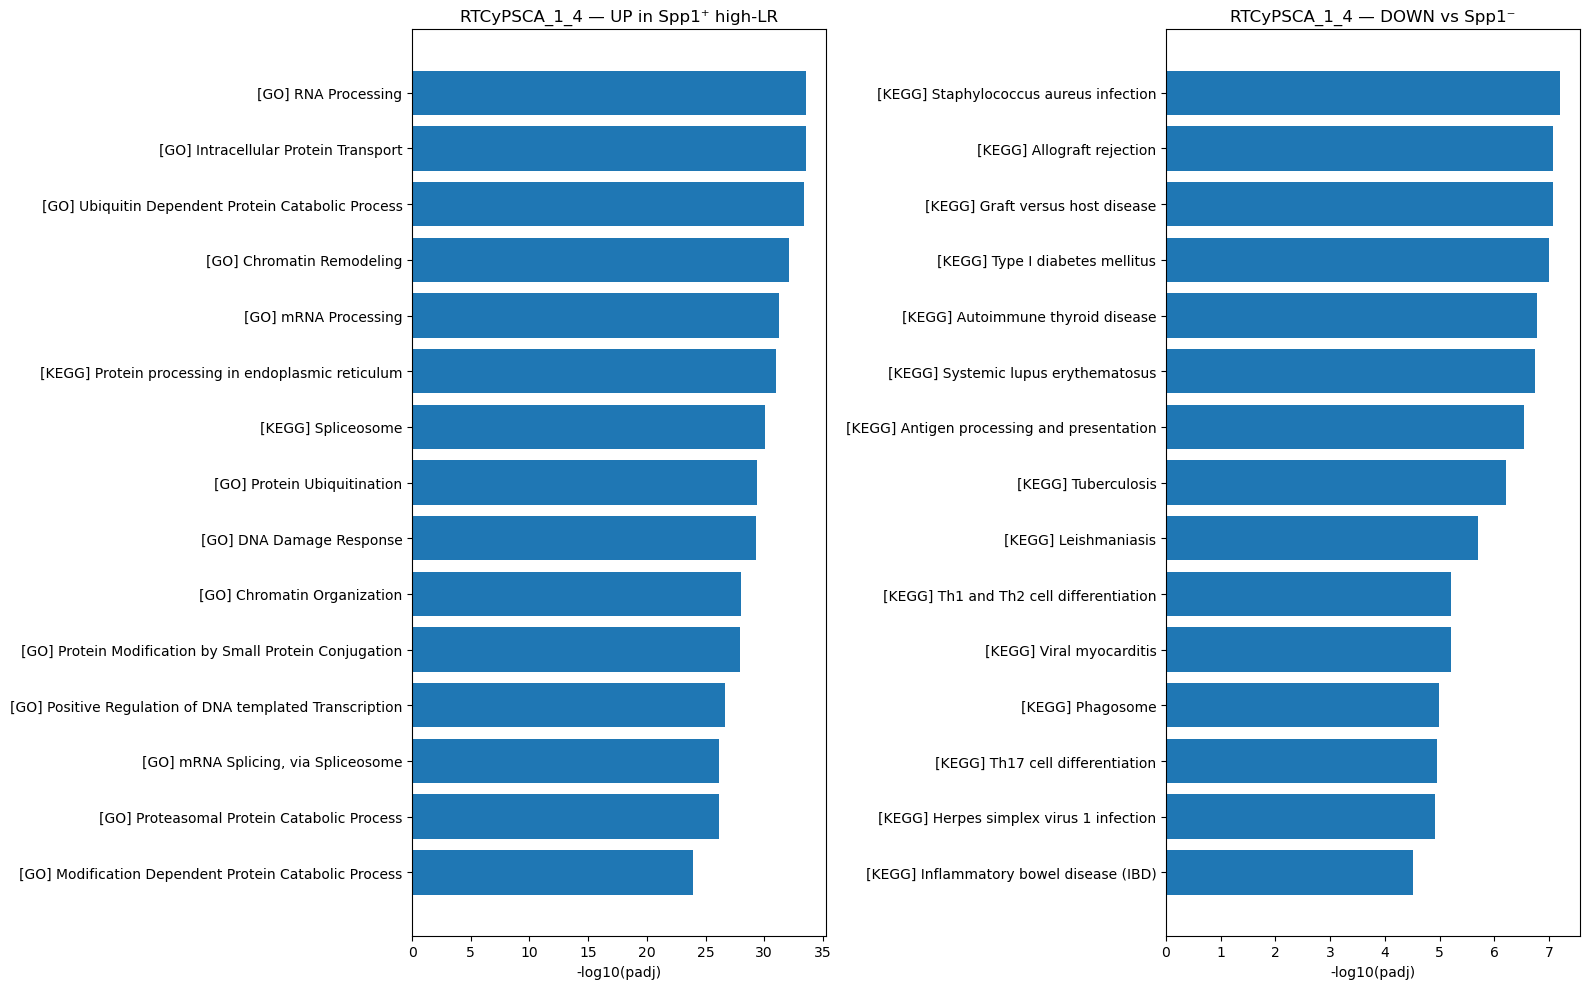

[RTCyPSCA_1_4] Saved combined enrichment figure -> RTCyPSCA_1_4__ENR_top15_up_and_down.png
running RTCyPSCA_2_4


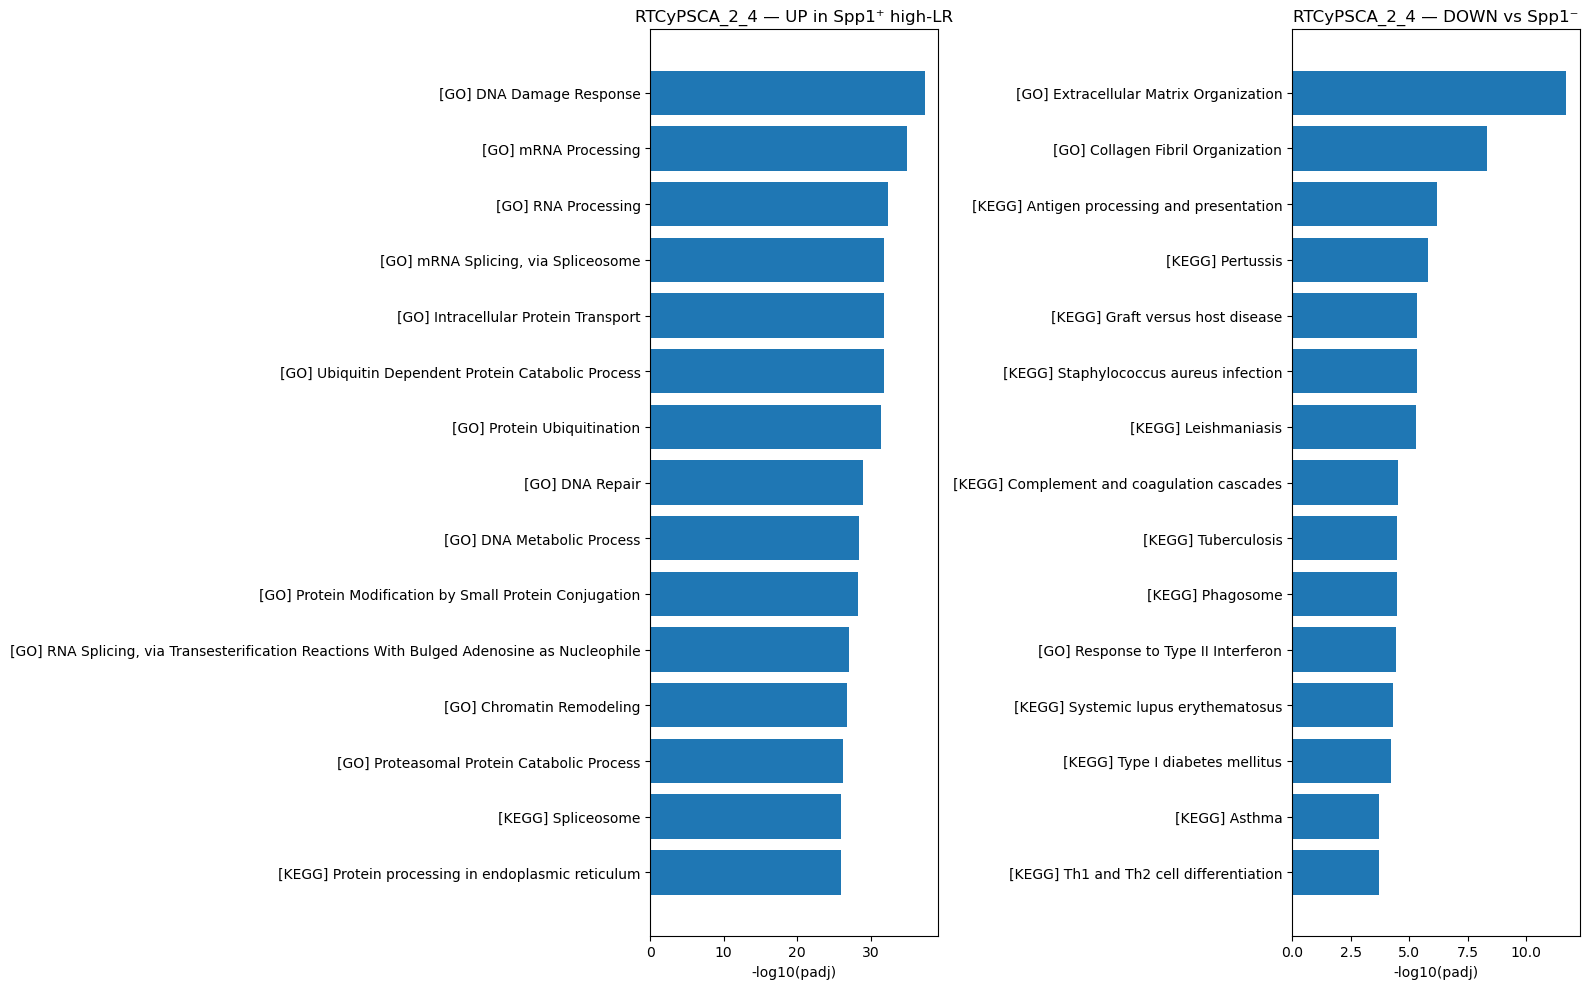

[RTCyPSCA_2_4] Saved combined enrichment figure -> RTCyPSCA_2_4__ENR_top15_up_and_down.png
running RTCyT72_2_1


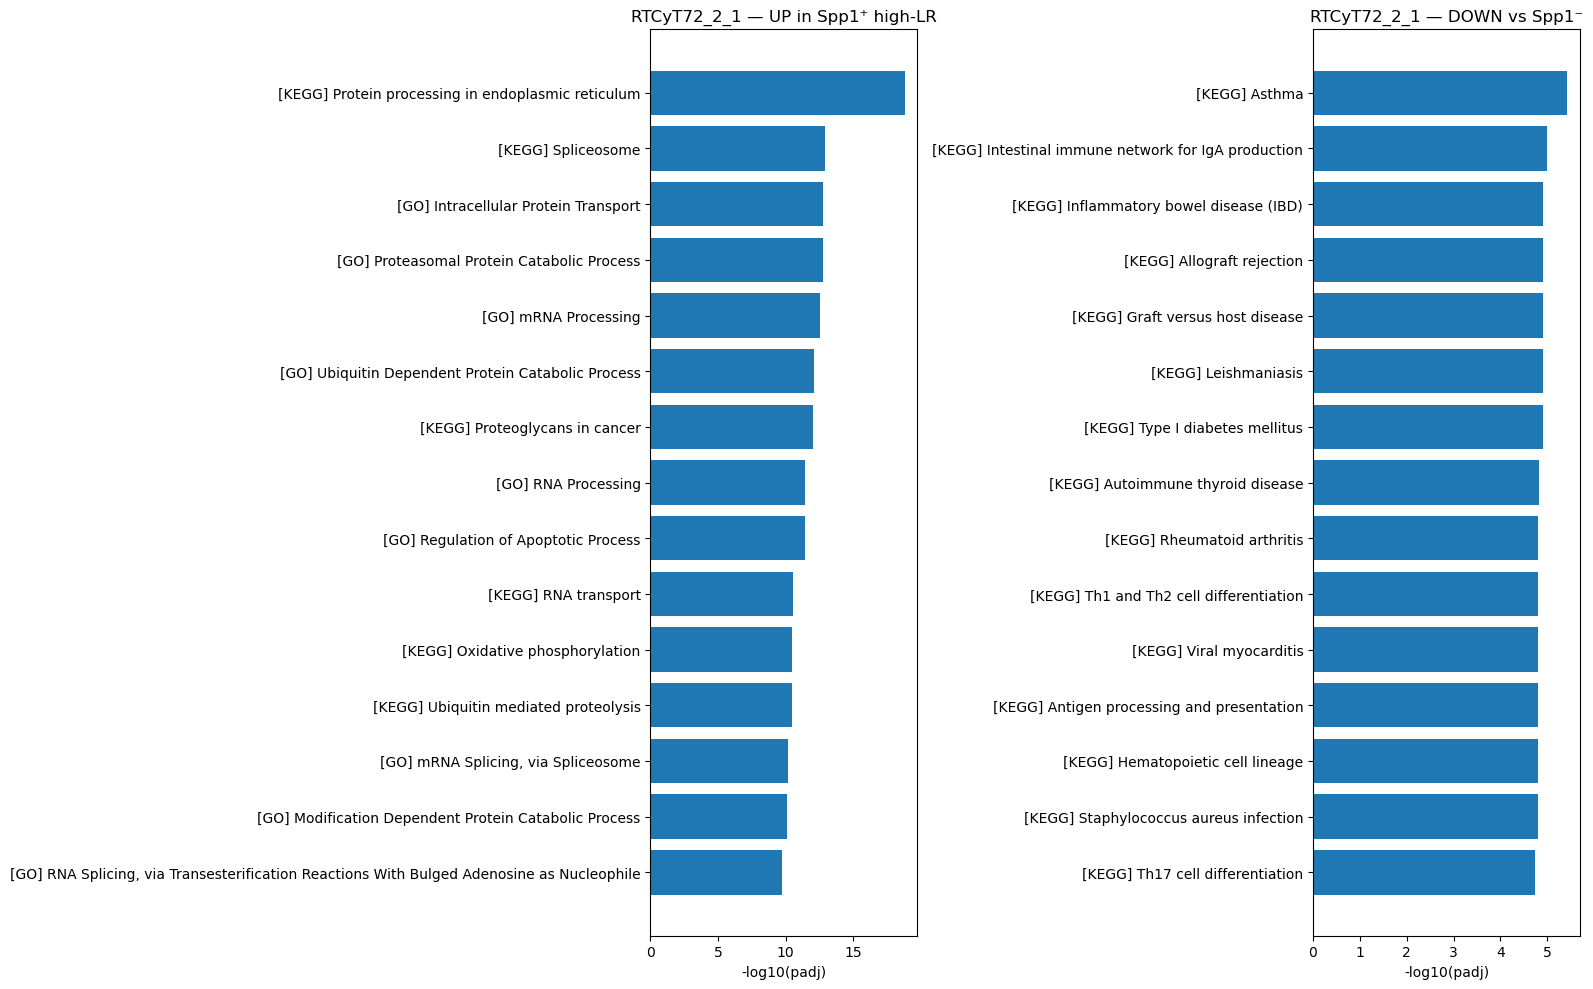

[RTCyT72_2_1] Saved combined enrichment figure -> RTCyT72_2_1__ENR_top15_up_and_down.png
running RTCyT72_2_4


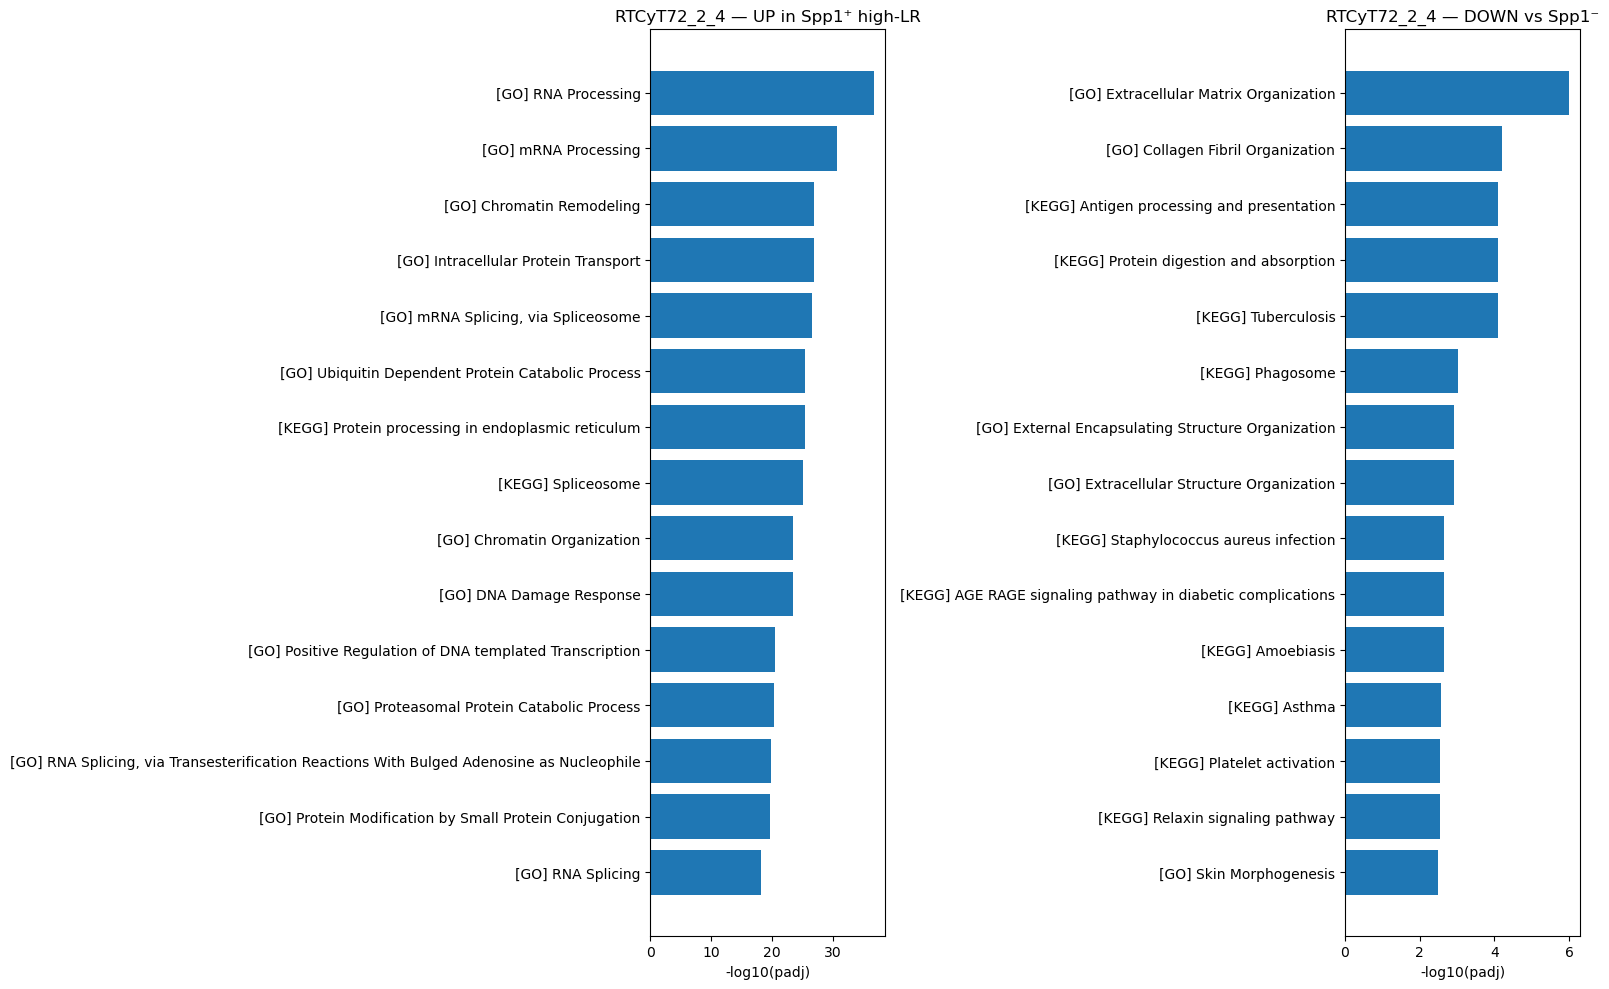

[RTCyT72_2_4] Saved combined enrichment figure -> RTCyT72_2_4__ENR_top15_up_and_down.png


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

# Choose libraries (you can add/remove)
ENR_LIBS = ["KEGG_2019_Mouse", "GO_Biological_Process_2025"]
out_ORA = outdir / "ORA_spp1.cd44_high.vs.spp1.neg"
out_ORA.mkdir(parents=True, exist_ok=True)

def run_enrich(gene_list, lib):
    if len(gene_list) == 0:
        return pd.DataFrame(columns=["Term","Adjusted P-value","Combined Score","Genes"])
    enr = gp.enrichr(gene_list=gene_list, gene_sets=lib, organism="Mouse", no_plot=True, outdir=None, cutoff=1.0)
    # standardize column names a bit
    res = enr.results.rename(columns={
        "Term":"term",
        "Adjusted P-value":"padj",
        "Combined Score":"combined_score",
        "Overlap":"overlap",
        "P-value":"pval"
    })
    return res[["term","padj","combined_score","overlap","pval","Genes"]].copy()

for m in mouse_list:
    print(f"running {m}")
    f = outdir / f"{m}__DE_Spp1posHighLR_vs_Spp1neg.csv"
    if not f.exists():
        continue
    df = pd.read_csv(f)

    # define up/down lists (padj < 0.05, log2FC threshold optional)
    up   = df.query("padj < 0.05 & log2FC > 0")["gene"].tolist()
    down = df.query("padj < 0.05 & log2FC < 0")["gene"].tolist()

    enr_up_all, enr_down_all = [], []
    for lib in ENR_LIBS:
        eu = run_enrich(up, lib)
        ed = run_enrich(down, lib)
        eu.insert(0, "library", lib); eu.insert(0, "direction", "Up")
        ed.insert(0, "library", lib); ed.insert(0, "direction", "Down")
        enr_up_all.append(eu); enr_down_all.append(ed)

    enr_up = (pd.concat(enr_up_all, ignore_index=True) if len(enr_up_all) else pd.DataFrame())
    enr_dn = (pd.concat(enr_down_all, ignore_index=True) if len(enr_down_all) else pd.DataFrame())

    # pick top 15 by padj (then combined score) per direction
    def topk(df):
        if df.empty:
            return df
        return df.sort_values(["padj","combined_score"], ascending=[True,False]).head(15)

    tup = topk(enr_up).copy()
    tdn = topk(enr_dn).copy()

    # Save enrichment tables
    tup.to_csv(out_ORA / f"{m}__ENR_up_top15.csv", index=False)
    tdn.to_csv(out_ORA / f"{m}__ENR_down_top15.csv", index=False)

    # --- Combined figure: top-15 UP (left) + top-15 DOWN (right) ---
    # We’ll plot -log10(padj); if padj==0, clip to 1e-300 to avoid inf
    def _prep_for_plot(d, keep_source_tag=True):
        if d.empty:
            return d
        d = d.copy()
    
        # ensure numeric padj then -log10
        d["padj"] = pd.to_numeric(d["padj"], errors="coerce").clip(lower=1e-300)
        d["neglog10_padj"] = -np.log10(d["padj"])
    
        # short source tag as a plain NumPy array (no pandas .str ops)
        src = d["library"].astype(str).str.upper().fillna("")
        tag_arr = np.where(src.str.contains("KEGG"), "[KEGG]",
                  np.where(src.str.contains("GO"),   "[GO]",
                  np.where(src.str.contains("REACTOME"), "[RXN]",
                  np.where(src.str.contains("WIKIPATHWAYS"), "[WP]", "[SRC]"))))
    
        # clean term text
        clean_term = (d["term"].astype(str)
                        .str.replace(r"[_\-]", " ", regex=True)
                        .str.replace(r"\s*\(GO:\d+\)\s*$", "", regex=True)
                        .str.strip())
    
        # build label with list comprehension -> avoids dtype/Index alignment issues
        if keep_source_tag:
            d["label"] = [f"{t} {ct}" for t, ct in zip(tag_arr, clean_term.tolist())]
        else:
            d["label"] = clean_term.tolist()
    
        return d

    tup = _prep_for_plot(tup)
    tdn = _prep_for_plot(tdn)

    nL = max(3, len(tup))
    nR = max(3, len(tdn))

    fig, axs = plt.subplots(1, 2, figsize=(16, 0.4*max(nL, nR) + 4), sharex=False)
    if not tup.empty:
        axs[0].barh(range(len(tup)), tup["neglog10_padj"])
        axs[0].set_yticks(range(len(tup))); axs[0].set_yticklabels(tup["label"])
        axs[0].invert_yaxis()
        axs[0].set_xlabel("-log10(padj)")
        axs[0].set_title(f"{m} — UP in Spp1⁺ high-LR")
    else:
        axs[0].text(0.5, 0.5, "No significant pathways", ha="center", va="center")
        axs[0].set_axis_off()

    if not tdn.empty:
        axs[1].barh(range(len(tdn)), tdn["neglog10_padj"])
        axs[1].set_yticks(range(len(tdn))); axs[1].set_yticklabels(tdn["label"])
        axs[1].invert_yaxis()
        axs[1].set_xlabel("-log10(padj)")
        axs[1].set_title(f"{m} — DOWN vs Spp1⁻")
    else:
        axs[1].text(0.5, 0.5, "No significant pathways", ha="center", va="center")
        axs[1].set_axis_off()

    plt.tight_layout()
    fig_path = out_ORA / f"{m}__ENR_top15_up_and_down.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[{m}] Saved combined enrichment figure -> {fig_path.name}")


# Spp1 neighbors

In [45]:
adata

AnnData object with n_obs × n_vars = 169773 × 16794
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mouse', 'sample_id', 'condition', 'cx', 'cy', 'TMA', 'library_id', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tumor_loc', 'M1_core_n', 'M1_acc_n', 'M2_core_n', 'M2_acc_n', 'M1_total', 'M2_total', 'M1_score_tiered', 'M2_score_tiered', 'Mac_polarization_tiered', 'Mac_like_tiered', 'Spp1_pos', 'Glp1r_pos', 'Mac_Spp1_pos', 'Mac_Glp1r_pos', 'Mac_marker_combo', 'LR_Spp1_Cd44', 'Mac_Spp1pos_highLR', 'Mac_Spp1neg', 'mac_lr_grp'
    var: 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'condition_colors', 'log1p', 'spatial', 'spatial_neighbors'
    obsm: 'X_cellcharter', 'X_scVI', 'spatial'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distanc

## Prep work

In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li

# Inputs already in your session:
# - adata: full AnnData with log1(CPM*1e6) in .X
# - adata.obs has:
#     'mouse'                (per-cell)
#     'Mac_Spp1pos_highLR'   (1/0)
#     'Mac_Spp1neg'          (1/0)
#     your macrophage flag column (e.g., 'Mac_like_tiered' or boolean 'is_mac')

mouse_key = "mouse"
mac_col   = "Mac_like_tiered"   # <-- change if your macrophage flag uses a different column
is_mac    = adata.obs[mac_col].astype(bool).values

# outputs
outdir = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/spp1.cd44.high.analysis")
DEout  = outdir / "DEspp1.neighbors"
ORAout = outdir / "ORAspp1.neighbors"
DEout.mkdir(parents=True, exist_ok=True)
ORAout.mkdir(parents=True, exist_ok=True)

# neighbor graph params (same scale as LIANA)
bandwidth = 40
cutoff    = 0.1
kernel    = "gaussian"

# sanity
req_cols = ["Mac_Spp1pos_highLR", "Mac_Spp1neg", mouse_key]
missing = [c for c in req_cols if c not in adata.obs.columns]
assert not missing, f"Missing required columns in adata.obs: {missing}"

mice = adata.obs[mouse_key].astype(str).unique().tolist()
print(f"Mice: {mice}")
print(f"Total cells: {adata.n_obs:,}; Non-macrophage cells: {(~is_mac).sum():,}")

# We’ll write a per-cell neighbor label (overwritten per mouse slice)
adata.obs["nbr_label"] = "none"  # 'Hnbr' for neighbors-of-High, 'Nnbr' for neighbors-of-Neg, 'none' otherwise

print("Outputs:")
print("  DE  ->", DEout)
print("  ORA ->", ORAout)


Mice: ['RTCyT72_2_1', 'RTCyPSCA_1_4', 'CyPSCA_1_1', 'NoTx_2_2', 'CyPSCA_1_2', 'RTCyT72_2_4', 'RTCyPSCA_2_4', 'CyT72_1_4']
Total cells: 169,773; Non-macrophage cells: 149,597
Outputs:
  DE  -> /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/spp1.cd44.high.analysis/DEspp1.neighbors
  ORA -> /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/spp1.cd44.high.analysis/ORAspp1.neighbors


## Identifying cell neighbors

In [114]:
from scipy import sparse

def exclusive_neighbor_labels(ad_m, anchors_H, anchors_N, cutoff_pos=0.0):
    """
    ad_m: per-mouse AnnData with obsp['spatial_connectivities'] built
    anchors_H / anchors_N: boolean arrays over ad_m.obs (True = anchor cell)
    cutoff_pos: > this value in connectivity counts as a neighbor (0.0 works when LIANA used cutoff=0.1)
    Returns two boolean arrays over ad_m.obs: Hnbr_excl, Nnbr_excl (exclusive, non-overlapping)
    """
    C = ad_m.obsp.get("spatial_connectivities", None)
    if C is None:
        raise ValueError("spatial_connectivities not found. Run li.ut.spatial_neighbors first.")

    # ensure CSR for fast row slicing
    C = C.tocsr() if not sparse.isspmatrix_csr(C) else C

    # union-of-neighbors for H and N (exclude self)
    H_idx = np.where(anchors_H)[0]
    N_idx = np.where(anchors_N)[0]

    Hnbr = np.zeros(ad_m.n_obs, dtype=bool)
    Nnbr = np.zeros(ad_m.n_obs, dtype=bool)

    if H_idx.size:
        # rows for H anchors -> neighbors are columns with weight > cutoff_pos
        H_block = C[H_idx, :].tocsr()
        if cutoff_pos > 0:
            # threshold by editing the data in-place: keep only edges > cutoff_pos
            Hb = H_block.copy()
            Hb.data = (Hb.data > cutoff_pos).astype(np.int8)
            Hnbr = (Hb.getnnz(axis=0) > 0).ravel()  # boolean 1D
        else:
            Hnbr = (H_block.getnnz(axis=0) > 0).ravel()

    if N_idx.size:
        N_block = C[N_idx, :].tocsr()
        if cutoff_pos > 0:
            Nb = N_block.copy()
            Nb.data = (Nb.data > cutoff_pos).astype(np.int8)
            Nnbr = (Nb.getnnz(axis=0) > 0).ravel()
        else:
            Nnbr = (N_block.getnnz(axis=0) > 0).ravel()


    # remove anchors themselves from neighbor sets
    Hnbr[H_idx] = False
    Nnbr[N_idx] = False

    # exclusivity: neighbors of H but NOT N, and vice-versa
    both = Hnbr & Nnbr
    H_excl = Hnbr & (~both)
    N_excl = Nnbr & (~both)

    return H_excl, N_excl

per_mouse_counts = []
for m in mice:
    ad_m = adata[adata.obs[mouse_key].astype(str) == m].copy()

    # Build per-mouse neighbors at same scale used for LIANA
    li.ut.spatial_neighbors(ad_m, bandwidth=bandwidth, cutoff=cutoff, kernel=kernel, set_diag=True)

    # anchors within this mouse
    H_anchor = (ad_m.obs["Mac_Spp1pos_highLR"] == 1).to_numpy()
    N_anchor = (ad_m.obs["Mac_Spp1neg"]        == 1).to_numpy()

    if H_anchor.sum() == 0 or N_anchor.sum() == 0:
        print(f"[{m}] skip: anchors missing (H={H_anchor.sum()}, N={N_anchor.sum()})")
        continue
    
    # exclusive neighbor sets (all cell types)
    Hnbr_excl, Nnbr_excl = exclusive_neighbor_labels(ad_m, H_anchor, N_anchor, cutoff_pos=0.0)

    # keep ONLY non-macrophages as requested
    non_mac_m = (~ad_m.obs[mac_col].astype(bool)).to_numpy()
    Hnbr_excl &= non_mac_m
    Nnbr_excl &= non_mac_m

    # write back into the main adata.obs['nbr_label'] for these indices
    idx_m = adata.obs.index[adata.obs[mouse_key].astype(str) == m]
    adata.obs.loc[idx_m, "nbr_label"] = "none"  # reset slice
    adata.obs.loc[idx_m[Hnbr_excl], "nbr_label"] = "Hnbr"
    adata.obs.loc[idx_m[Nnbr_excl], "nbr_label"] = "Nnbr"

    per_mouse_counts.append({
        "mouse": m,
        "H_anchors": int(H_anchor.sum()),
        "N_anchors": int(N_anchor.sum()),
        "Hnbr_nonmac": int(Hnbr_excl.sum()),
        "Nnbr_nonmac": int(Nnbr_excl.sum())
    })

counts_df = pd.DataFrame(per_mouse_counts).sort_values("mouse")
display(counts_df)
print("Done neighbor labeling (exclusive, non-macrophages).")


,mouse,H_anchors,N_anchors,Hnbr_nonmac,Nnbr_nonmac
2,CyPSCA_1_1,730,1158,4711,5308
4,CyPSCA_1_2,922,714,2293,1695
7,CyT72_1_4,68,321,255,7664
3,NoTx_2_2,97,33,6396,2440
1,RTCyPSCA_1_4,267,868,841,5420
6,RTCyPSCA_2_4,617,851,2338,5886
0,RTCyT72_2_1,67,198,1235,8555
5,RTCyT72_2_4,347,480,2795,13152


Done neighbor labeling (exclusive, non-macrophages).


In [116]:
adata.obs['nbr_label'].unique()

array(['Nnbr', 'none', 'Hnbr'], dtype=object)

## DE

In [50]:
import scanpy as sc
import numpy as np
import pandas as pd

MIN_CELLS = 25  # require some support per group

def rg_to_df(ad, group="Hnbr"):
    rg = ad.uns["rank_genes_groups"]
    k  = group
    return pd.DataFrame({
        "gene": rg["names"][k],
        "log2FC": rg["logfoldchanges"][k],
        "pval": rg["pvals"][k],
        "padj": rg["pvals_adj"][k],
        "scores": rg["scores"][k],
        "pct_in_group": rg.get("pts", {}).get(k, np.nan),
        "pct_ref":     rg.get("pts_rest", {}).get(k, np.nan),
    })

de_summaries = []
for m in mice:
    sub = adata[(adata.obs[mouse_key].astype(str)==m) & (adata.obs["nbr_label"].isin(["Hnbr","Nnbr"]))].copy()
    if sub.n_obs == 0:
        continue

    nH = int((sub.obs["nbr_label"]=="Hnbr").sum())
    nN = int((sub.obs["nbr_label"]=="Nnbr").sum())
    if (nH < MIN_CELLS) or (nN < MIN_CELLS):
        print(f"[{m}] skip DE (Hnbr={nH}, Nnbr={nN})")
        continue

    # keep genes seen in a few cells to stabilize ranks
    sc.pp.filter_genes(sub, min_cells=5)

    # DE: Hnbr vs Nnbr (single-cell Wilcoxon) — data already log-transformed; do NOT re-normalize
    sc.tl.rank_genes_groups(
        sub, groupby="nbr_label",
        groups=["Hnbr"], reference="Nnbr",
        method="wilcoxon", corr_method="benjamini-hochberg",
        tie_correct=True, n_genes=sub.n_vars,
        use_raw=False
    )
    df = rg_to_df(sub, group="Hnbr")
    df.insert(0, "mouse", m)

    out_csv = DEout / f"{m}__DE_Hnbr_vs_Nnbr_nonmac.csv"
    df.to_csv(out_csv, index=False)
    print(f"[{m}] DE rows: {df.shape[0]} -> {out_csv.name}")

    de_summaries.append({"mouse": m, "cells_Hnbr": nH, "cells_Nnbr": nN, "genes_padj<0.05": int((df["padj"]<0.05).sum())})

display(pd.DataFrame(de_summaries).sort_values("mouse"))


... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical


[RTCyT72_2_1] DE rows: 11416 -> RTCyT72_2_1__DE_Hnbr_vs_Nnbr_nonmac.csv


... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical


[RTCyPSCA_1_4] DE rows: 10986 -> RTCyPSCA_1_4__DE_Hnbr_vs_Nnbr_nonmac.csv


... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical


...

... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical


[RTCyPSCA_2_4] DE rows: 11713 -> RTCyPSCA_2_4__DE_Hnbr_vs_Nnbr_nonmac.csv


... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical


[CyT72_1_4] DE rows: 11187 -> CyT72_1_4__DE_Hnbr_vs_Nnbr_nonmac.csv


,mouse,cells_Hnbr,cells_Nnbr,genes_padj<0.05
2,CyPSCA_1_1,4711,5308,7848
4,CyPSCA_1_2,2293,1695,6028
7,CyT72_1_4,255,7664,1442
3,NoTx_2_2,6396,2440,88
1,RTCyPSCA_1_4,841,5420,8272
6,RTCyPSCA_2_4,2338,5886,8990
0,RTCyT72_2_1,1235,8555,4612
5,RTCyT72_2_4,2795,13152,8217


## ORA

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

# Pick libraries (latest available preferred; neutral GO/Reactome are fine for mouse;
# use KEGG_Mouse if present on your Enrichr server)
ENR_LIBS = ["KEGG_2019_Mouse", "GO_Biological_Process_2025"] # <-- edit if you have newer on your server
ORAout_full = ORAout / "full_results"
ORAout_full.mkdir(parents=True, exist_ok=True)

def run_enrich(gene_list, lib):
    if len(gene_list) == 0:
        return pd.DataFrame(columns=["term","padj","combined_score","overlap","pval","Genes"])
    enr = gp.enrichr(gene_list=gene_list, gene_sets=lib, organism="Mouse", no_plot=True, outdir=None, cutoff=1.0)
    res = enr.results.rename(columns={
        "Term":"term",
        "Adjusted P-value":"padj",
        "Combined Score":"combined_score",
        "Overlap":"overlap",
        "P-value":"pval"
    })
    # coerce padj numeric for safety
    res["padj"] = pd.to_numeric(res["padj"], errors="coerce")
    return res[["term","padj","combined_score","overlap","pval","Genes"]].copy()

def _prep_for_plot(d, keep_source_tag=True):
    if d.empty:
        return d
    d = d.copy()

    # stats
    d["padj"] = pd.to_numeric(d["padj"], errors="coerce").clip(lower=1e-300)
    d["neglog10_padj"] = -np.log10(d["padj"])

    # source tag from library
    libu = d["library"].astype(str).str.upper()
    tag_arr = np.where(libu.str.contains("KEGG"), "[KEGG]",
              np.where(libu.str.contains("GO"),   "[GO]",
              np.where(libu.str.contains("REACTOME"), "[RXN]",
              np.where(libu.str.contains("WIKIPATHWAYS"), "[WP]", "[SRC]"))))

    # clean term text
    clean_term = (d["term"].astype(str)
                    .str.replace(r"[_\-]", " ", regex=True)
                    .str.replace(r"\s*\(GO:\d+\)\s*$", "", regex=True)
                    .str.strip())

    # labels with or without tag
    d["label"] = [f"{t} {ct}" for t, ct in zip(tag_arr, clean_term.tolist())] if keep_source_tag else clean_term.tolist()
    return d

for m in mice:
    f = DEout / f"{m}__DE_Hnbr_vs_Nnbr_nonmac.csv"
    if not f.exists():
        continue
    df = pd.read_csv(f)

    up   = df.query("padj < 0.05 & log2FC > 0")["gene"].tolist()
    down = df.query("padj < 0.05 & log2FC < 0")["gene"].tolist()

    enr_up_all, enr_dn_all = [], []
    for lib in ENR_LIBS:
        eu = run_enrich(up, lib);  eu.insert(0, "library", lib);  eu.insert(0, "direction", "Up");   enr_up_all.append(eu)
        ed = run_enrich(down, lib);ed.insert(0, "library", lib);  ed.insert(0, "direction", "Down"); enr_dn_all.append(ed)

    enr_up = pd.concat(enr_up_all, ignore_index=True) if len(enr_up_all) else pd.DataFrame()
    enr_dn = pd.concat(enr_dn_all, ignore_index=True) if len(enr_dn_all) else pd.DataFrame()

      # --- save FULL results (per direction + combined), with a short source tag ---
    def _src_tag(s):
        s = s.astype(str).str.upper()
        return np.where(s.str.contains("KEGG"), "KEGG",
               np.where(s.str.contains("GO"),   "GO",
               np.where(s.str.contains("REACTOME"), "RXN",
               np.where(s.str.contains("WIKIPATHWAYS"), "WP", "SRC"))))

    if not enr_up.empty:
        enr_up_full = enr_up.copy()
        enr_up_full["source"] = _src_tag(enr_up_full["library"])
        enr_up_full.to_csv(ORAout_full / f"{m}__ORA_full_UP_Hnbr_vs_Nnbr.csv", index=False)

    if not enr_dn.empty:
        enr_dn_full = enr_dn.copy()
        enr_dn_full["source"] = _src_tag(enr_dn_full["library"])
        enr_dn_full.to_csv(ORAout_full / f"{m}__ORA_full_DOWN_Hnbr_vs_Nnbr.csv", index=False)

    # combined full (both directions in one table)
    if (not enr_up.empty) or (not enr_dn.empty):
        full_all = pd.concat([enr_up.assign(direction="Up"), enr_dn.assign(direction="Down")], ignore_index=True)
        full_all["source"] = _src_tag(full_all["library"])
        full_all.to_csv(ORAout_full / f"{m}__ORA_full_ALL_Hnbr_vs_Nnbr.csv", index=False)
    
    def topk(x):
        if x.empty: return x
        return x.sort_values(["padj","combined_score"], ascending=[True,False]).head(15)

    tup = _prep_for_plot(topk(enr_up))
    tdn = _prep_for_plot(topk(enr_dn))

    # pick top-15 per direction
    tup_raw = topk(enr_up).copy()
    tdn_raw = topk(enr_dn).copy()

    # save TOP-15 tables (keep raw stats; add source tag col)
    if not tup_raw.empty:
        tup_raw["source"] = np.where(tup_raw["library"].str.contains("KEGG", case=False), "KEGG",
                              np.where(tup_raw["library"].str.contains("GO", case=False), "GO", "OTHER"))
        tup_raw.to_csv(ORAout / f"{m}__ORA_up_top15_Hnbr_vs_Nnbr.csv", index=False)

    if not tdn_raw.empty:
        tdn_raw["source"] = np.where(tdn_raw["library"].str.contains("KEGG", case=False), "KEGG",
                              np.where(tdn_raw["library"].str.contains("GO", case=False), "GO", "OTHER"))
        tdn_raw.to_csv(ORAout / f"{m}__ORA_down_top15_Hnbr_vs_Nnbr.csv", index=False)

    # prep labels for plotting (adds [GO]/[KEGG] and cleans terms)
    tup = _prep_for_plot(tup_raw, keep_source_tag=True)
    tdn = _prep_for_plot(tdn_raw, keep_source_tag=True)
    
    # combined figure
    nL, nR = max(3, len(tup)), max(3, len(tdn))
    fig, axs = plt.subplots(1, 2, figsize=(16, 0.4*max(nL, nR) + 4), sharex=False)

    if not tup.empty:
        axs[0].barh(range(len(tup)), tup["neglog10_padj"])
        axs[0].set_yticks(range(len(tup))); axs[0].set_yticklabels(tup["label"])
        axs[0].invert_yaxis(); axs[0].set_xlabel("-log10(padj)")
        axs[0].set_title(f"{m} — UP: H-neighbors vs N-neighbors")
    else:
        axs[0].text(0.5, 0.5, "No significant pathways", ha="center", va="center"); axs[0].set_axis_off()

    if not tdn.empty:
        axs[1].barh(range(len(tdn)), tdn["neglog10_padj"])
        axs[1].set_yticks(range(len(tdn))); axs[1].set_yticklabels(tdn["label"])
        axs[1].invert_yaxis(); axs[1].set_xlabel("-log10(padj)")
        axs[1].set_title(f"{m} — DOWN: H-neighbors vs N-neighbors")
    else:
        axs[1].text(0.5, 0.5, "No significant pathways", ha="center", va="center"); axs[1].set_axis_off()

    fig_path = ORAout / f"{m}__ORA_top15_up_down_Hnbr_vs_Nnbr.png"
    plt.tight_layout(); plt.savefig(fig_path, dpi=300, bbox_inches="tight"); plt.close()
    print(f"[{m}] Saved ORA -> {fig_path.name}")


[RTCyT72_2_1] Saved ORA -> RTCyT72_2_1__ORA_top15_up_down_Hnbr_vs_Nnbr.png
[RTCyPSCA_1_4] Saved ORA -> RTCyPSCA_1_4__ORA_top15_up_down_Hnbr_vs_Nnbr.png
[CyPSCA_1_1] Saved ORA -> CyPSCA_1_1__ORA_top15_up_down_Hnbr_vs_Nnbr.png
[NoTx_2_2] Saved ORA -> NoTx_2_2__ORA_top15_up_down_Hnbr_vs_Nnbr.png
[CyPSCA_1_2] Saved ORA -> CyPSCA_1_2__ORA_top15_up_down_Hnbr_vs_Nnbr.png
[RTCyT72_2_4] Saved ORA -> RTCyT72_2_4__ORA_top15_up_down_Hnbr_vs_Nnbr.png
[RTCyPSCA_2_4] Saved ORA -> RTCyPSCA_2_4__ORA_top15_up_down_Hnbr_vs_Nnbr.png
[CyT72_1_4] Saved ORA -> CyT72_1_4__ORA_top15_up_down_Hnbr_vs_Nnbr.png


### Learning

In [57]:
f = DEout / "RTCyPSCA_2_4__DE_Hnbr_vs_Nnbr_nonmac.csv"

In [62]:
f

PosixPath('/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/spp1.cd44.high.analysis/DEspp1.neighbors/RTCyPSCA_2_4__DE_Hnbr_vs_Nnbr_nonmac.csv')

In [60]:
df = pd.read_csv(f)

In [61]:
df.head()

,mouse,gene,log2FC,pval,padj,scores,pct_in_group,pct_ref
0,RTCyPSCA_2_4,Spp1,6.817257,0.000000e+00,0.000000e+00,42.733230,NaN,NaN
1,RTCyPSCA_2_4,Clu,5.897120,0.000000e+00,0.000000e+00,38.223236,NaN,NaN
2,RTCyPSCA_2_4,S100a6,5.547246,3.449390e-248,1.346757e-244,33.647000,NaN,NaN
3,RTCyPSCA_2_4,Areg,4.442025,1.318032e-233,2.573019e-230,32.634770,NaN,NaN
4,RTCyPSCA_2_4,Ibsp,4.492654,1.431355e-227,2.395066e-224,32.206497,NaN,NaN


In [79]:
up = df.query("padj < 0.05 & log2FC > 0 ")['gene'].tolist()
down = df.query("padj < 0.05 & log2FC < 0 ")['gene'].tolist()

In [81]:
enr_up = run_enrich(up, ENR_LIBS[0])

In [ ]:

enr_up_all, enr_dn_all = [], []
for lib in ENR_LIBS:
    eu = run_enrich(up, lib);  eu.insert(0, "library", lib);  eu.insert(0, "direction", "Up");   enr_up_all.append(eu)
    ed = run_enrich(down, lib);ed.insert(0, "library", lib);  ed.insert(0, "direction", "Down"); enr_dn_all.append(ed)

enr_up = pd.concat(enr_up_all, ignore_index=True) if len(enr_up_all) else pd.DataFrame()
enr_dn = pd.concat(enr_dn_all, ignore_index=True) if len(enr_dn_all) else pd.DataFrame()

  # --- save FULL results (per direction + combined), with a short source tag ---
def _src_tag(s):
    s = s.astype(str).str.upper()
    return np.where(s.str.contains("KEGG"), "KEGG",
           np.where(s.str.contains("GO"),   "GO",
           np.where(s.str.contains("REACTOME"), "RXN",
           np.where(s.str.contains("WIKIPATHWAYS"), "WP", "SRC"))))

up   = df.query("padj < 0.05 & log2FC > 0")["gene"].tolist()
down = df.query("padj < 0.05 & log2FC < 0")["gene"].tolist()


# Summary

In [55]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---- config ----
p = ""  # set to your write_prefix if you used one, e.g., p="RT_"
mouse_key = "mouse"
out_loc = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/")
out_loc.mkdir(parents=True, exist_ok=True)
out_csv = out_loc / "mac_annotation_counts_per_mouse.csv"
# ----------------

# required columns
req = [
    f"{p}Mac_polarization_tiered",
    f"{p}Mac_like_tiered",
    f"{p}Mac_marker_combo",
    f"{p}Spp1_pos",
    f"{p}Glp1r_pos",
]
missing = [c for c in req + [mouse_key] if c not in adata.obs.columns]
if missing:
    raise ValueError(f"Missing columns in adata.obs: {missing}")

obs = adata.obs[[mouse_key, *req]].copy()

# helper to get categorical counts with zero-filled categories
def cat_counts(df, by, col, categories):
    # enforce categories so absent ones appear with 0
    s = (df.groupby(by)[col]
           .apply(lambda x: x.astype(pd.CategoricalDtype(categories=categories))
                             .value_counts())
           .unstack(fill_value=0))
    # standardize column names
    s = s.reindex(columns=categories, fill_value=0)
    s.columns = [f"{col}__{c}" for c in s.columns]
    return s

# 1) basic totals
per_mouse = obs.groupby(mouse_key).size().rename("n_cells").to_frame()

# 2) macrophage-like (any) vs non-mac
# Mac_like_tiered is 0/1
mac_like = (obs.groupby(mouse_key)[f"{p}Mac_like_tiered"]
              .agg(n_mac_like="sum"))
mac_like["n_non_mac"] = per_mouse["n_cells"] - mac_like["n_mac_like"]
per_mouse = per_mouse.join(mac_like)

# 3) Spp1/Glp1r overall (any cell)
bin_cols = [f"{p}Spp1_pos", f"{p}Glp1r_pos"]
for bc in bin_cols:
    per_mouse[f"{bc}__sum_all"] = obs.groupby(mouse_key)[bc].sum()

# 4) Spp1/Glp1r among macrophage-like only
obs_mac = obs[obs[f"{p}Mac_like_tiered"].astype(bool)].copy()
for bc in bin_cols:
    per_mouse[f"{bc}__sum_mac"] = obs_mac.groupby(mouse_key)[bc].sum()

# 5) polarization class counts per mouse
pol_cats = ["M1","M2","Both","Neither"]
pol_counts = cat_counts(obs, mouse_key, f"{p}Mac_polarization_tiered", pol_cats)

# 6) macrophage marker combos per mouse
combo_cats = ["Non-mac","None","Spp1","Glp1r","Both"]
combo_counts = cat_counts(obs, mouse_key, f"{p}Mac_marker_combo", combo_cats)

# 7) combine
summary = per_mouse.join(pol_counts, how="left").join(combo_counts, how="left")

# 8) (optional) add rates within macs
with np.errstate(divide='ignore', invalid='ignore'):
    denom = summary["n_mac_like"].replace(0, np.nan)
    for c in ["M1","M2","Both","Neither"]:
        col = f"{p}Mac_polarization_tiered__{c}"
        summary[f"{col}__frac_mac"] = summary[col] / denom
    for c in ["None","Spp1","Glp1r","Both"]:
        col = f"{p}Mac_marker_combo__{c}"
        summary[f"{col}__frac_mac"] = summary[col] / denom

# 9) save
summary.sort_index().to_csv(out_csv)
print(f"Wrote per-mouse annotation counts to: {out_csv}")

# quick peek
summary.head(10)


Wrote per-mouse annotation counts to: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/mac_annotation_counts_per_mouse.csv


/tmp/ipykernel_2376/3017912625.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_2376/3017912625.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_2376/3017912625.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_2376/3017912625.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to

,n_cells,n_mac_like,n_non_mac,Spp1_pos__sum_all,Glp1r_pos__sum_all,Spp1_pos__sum_mac,Glp1r_pos__sum_mac,Mac_polarization_tiered__M1,Mac_polarization_tiered__M2,Mac_polarization_tiered__Both,...,Mac_marker_combo__Glp1r,Mac_marker_combo__Both,Mac_polarization_tiered__M1__frac_mac,Mac_polarization_tiered__M2__frac_mac,Mac_polarization_tiered__Both__frac_mac,Mac_polarization_tiered__Neither__frac_mac,Mac_marker_combo__None__frac_mac,Mac_marker_combo__Spp1__frac_mac,Mac_marker_combo__Glp1r__frac_mac,Mac_marker_combo__Both__frac_mac
mouse,,,,,,,,,,,,,,,,,,,,,
CyPSCA_1_1,27254,4805,22449,18879,177,3647,39,4241,560,4,...,3,36,0.882622,0.116545,0.000832,4.672008,0.240375,0.751509,0.000624,0.007492
CyPSCA_1_2,15179,5320,9859,12311,144,4606,64,4300,978,42,...,3,61,0.808271,0.183835,0.007895,1.853195,0.133647,0.854323,0.000564,0.011466
CyT72_1_4,13636,661,12975,3459,15,340,4,378,283,0,...,1,3,0.571861,0.428139,0.000000,19.629349,0.484115,0.509834,0.001513,0.004539
NoTx_2_2,36255,516,35739,29012,1451,483,30,104,412,0,...,0,30,0.201550,0.798450,0.000000,69.261628,0.063953,0.877907,0.000000,0.058140
RTCyPSCA_1_4,12667,2199,10468,5472,63,1331,18,1965,225,9,...,0,18,0.893588,0.102319,0.004093,4.760346,0.394725,0.597090,0.000000,0.008186
RTCyPSCA_2_4,18697,3932,14765,11070,313,3081,108,2777,1135,20,...,7,101,0.706256,0.288657,0.005086,3.755086,0.214649,0.757884,0.001780,0.025687
RTCyT72_2_1,17578,532,17046,6378,63,334,6,283,249,0,...,1,5,0.531955,0.468045,0.000000,32.041353,0.370301,0.618421,0.001880,0.009398
RTCyT72_2_4,28507,2211,26296,13481,157,1731,42,1075,1134,2,...,1,41,0.486205,0.512890,0.000905,11.893261,0.216644,0.764360,0.000452,0.018544


In [95]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mouse_key   = "mouse"
mac_col     = "Mac_like_tiered"          # 1/0
spp1_col    = "Spp1_pos"                 # 1/0
highlr_col  = "Mac_Spp1pos_highLR"       # 1/0 (defined earlier)
out_dir     = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/accross.samples")
out_dir.mkdir(parents=True, exist_ok=True)

In [96]:
# sanity
req = [mouse_key, mac_col, spp1_col, highlr_col]
missing = [c for c in req if c not in adata.obs.columns]
assert not missing, f"Missing columns: {missing}"

In [97]:
obs = adata.obs[[mouse_key, mac_col, spp1_col, highlr_col]].copy()
obs["is_mac"]      = obs[mac_col].astype(bool).values
obs["is_spp1pos"]  = obs[spp1_col].astype(int).values == 1
obs["is_highLR"]   = obs[highlr_col].astype(int).values == 1  # Spp1⁺ + high LR by construction

# per-mouse tallies
g = obs.groupby(mouse_key)
n_cells      = g.size().rename("n_cells")
n_mac        = g["is_mac"].sum().rename("n_mac")
n_spp1pos    = g.apply(lambda d: int((d["is_mac"] & d["is_spp1pos"]).sum())).rename("n_spp1pos_mac")
n_highLR     = g["is_highLR"].sum().rename("n_spp1pos_highLR_mac")

summary = pd.concat([n_cells, n_mac, n_spp1pos, n_highLR], axis=1)
# rates
summary["frac_highLR_among_mac"]      = summary["n_spp1pos_highLR_mac"] / summary["n_mac"].replace(0, np.nan)
summary["frac_highLR_among_spp1pos"]  = summary["n_spp1pos_highLR_mac"] / summary["n_spp1pos_mac"].replace(0, np.nan)

# save
csv_path = out_dir / "per_mouse_Mac_Spp1pos_highLR_summary.csv"
summary.sort_index().to_csv(csv_path)
print("Wrote:", csv_path)

# optional: barplot of fraction among Spp1+ macs per mouse
plt.figure(figsize=(10, 4))
summary.sort_values("frac_highLR_among_spp1pos")["frac_highLR_among_spp1pos"].plot(kind="bar")
plt.ylabel("High-LR among Spp1⁺ macs (fraction)")
plt.title("Mac_Spp1pos_highLR across mice")
plt.tight_layout()
plt.savefig(out_dir / "per_mouse_highLR_fraction_among_spp1pos.png", dpi=300)
plt.close()

/tmp/ipykernel_2376/1264547629.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_2376/1264547629.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


Wrote: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/accross.samples/per_mouse_Mac_Spp1pos_highLR_summary.csv


# Accross samples

## Spp1.CD44 High comparisons

In [107]:
# -------- CONFIG --------
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import gseapy as gp

out_dir = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/accross.samples")
out_dir.mkdir(parents=True, exist_ok=True)

mouse_key   = "mouse"
mac_flag    = "Mac_like_tiered"          # 1/0 macrophage gate from your annotation
high_flag   = "Mac_Spp1pos_highLR"       # 1/0 Spp1|Cd44-high (per-mouse quantile)
MIN_CELLS   = 60                         # minimum high-LR mac cells per side
ENR_LIBS    = ["KEGG_2019_Mouse", "GO_Biological_Process_2025"]  # adjust if you have newer libs

# --- cohorts as you specified ---
CYP_combined     = ["CyPSCA_1_1", "CyPSCA_1_2"]
RTCYT72_combined = ["RTCyT72_2_1", "RTCyT72_2_4"]

singletons = {
    "CyT72_1_4":      ["CyT72_1_4"],
    "NoTx_2_2":       ["NoTx_2_2"],
    "RTCyPSCA_1_4":   ["RTCyPSCA_1_4"],
    "RTCyPSCA_2_4":   ["RTCyPSCA_2_4"],
}

In [108]:
# Pairs:
pairs = []

# CyPSCA replicates vs each other mouse/group (including RTCyT72 combined)
for other_name, other_members in (list(singletons.items()) + [("RTCyT72_combined", RTCYT72_combined)]):
    pairs.append( ("CyPSCA_combined", CYP_combined, other_name, other_members) )

# RTCyT72 replicates vs each other mouse/group (including CyPSCA combined)
for other_name, other_members in (list(singletons.items()) + [("CyPSCA_combined", CYP_combined)]):
    pairs.append( ("RTCyT72_combined", RTCYT72_combined, other_name, other_members) )

# Pairwise among the 4 singletons (6 comparisons)
singleton_names = list(singletons.keys())
for i in range(len(singleton_names)):
    for j in range(i+1, len(singleton_names)):
        A = singleton_names[i]; B = singleton_names[j]
        pairs.append( (A, singletons[A], B, singletons[B]) )

print(f"Total comparisons planned: {len(pairs)}")  # expected 16

Total comparisons planned: 16


In [109]:
# -------- HELPERS --------
def _rank_df_from_scanpy(ad, group):
    rg = ad.uns["rank_genes_groups"]
    k  = group
    df = pd.DataFrame({
        "gene": rg["names"][k],
        "log2FC": rg["logfoldchanges"][k],
        "pval": rg["pvals"][k],
        "padj": rg["pvals_adj"][k],
        "scores": rg["scores"][k],
        "pct_in_group": rg.get("pts", {}).get(k, np.nan),
        "pct_ref":      rg.get("pts_rest", {}).get(k, np.nan),
    })
    df["pval"] = pd.to_numeric(df["pval"], errors="coerce")
    df["padj"] = pd.to_numeric(df["padj"], errors="coerce")
    return df

def _volcano(df, title, out_png):
    x = df["log2FC"].astype(float)
    y = -np.log10(df["padj"].clip(lower=1e-300))
    plt.figure(figsize=(6.5,5))
    plt.scatter(x, y, s=4, alpha=0.6)
    plt.axvline(0, ls="--", lw=1)
    plt.xlabel("log2FC (A / B)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def _col(df, *cands):
    low = {c.lower(): c for c in df.columns}
    for c in cands:
        if c in df.columns: return c
        if c.lower() in low: return low[c.lower()]
    raise KeyError(f"Missing columns {cands} in {list(df.columns)}")

def run_preranked_gsea(df, lib_list, out_folder, title_stub):
    """
    Ranked GSEA with score = log2FC * -log10(pval), one run per library.
    Writes full CSV per lib and combined Top-15 Up/Down PNG across libs.
    """
    out_folder.mkdir(parents=True, exist_ok=True)
    # rank metric
    r = df[["gene","log2FC","pval"]].dropna().copy()
    r["rank"] = r["log2FC"] * (-np.log10(r["pval"].clip(lower=1e-300)))
    r = r[["gene","rank"]]

    # break ties very slightly
    if r["rank"].duplicated().any():
        rng = np.random.RandomState(0)
        r.loc[:, "rank"] = r["rank"].values + 1e-9 * rng.randn(len(r))

    all_res = []
    for lib in lib_list:
        pr = gp.prerank(rnk=r, gene_sets=lib, min_size=10, max_size=500, threads=4, seed=0, verbose=False)
        res = pr.res2d.copy()
        if res is None or res.empty:
            continue
        res["library"] = lib
        # standardize columns
        term = _col(res, "Term", "term", "Gene_set", "Name")
        nes  = _col(res, "NES", "nes")
        fdr  = _col(res, "FDR q-val", "FDR", "fdr", "fdr_q_val")
        res.rename(columns={term:"term", nes:"NES", fdr:"FDR"}, inplace=True)
        # save full per-lib table
        res.sort_values(["FDR","NES"], ascending=[True, False]).to_csv(out_folder / f"{title_stub}__{lib}__GSEA_full.csv", index=False)
        all_res.append(res[["term","NES","FDR","library"]])

    if not all_res:
        print("  [GSEA] no results")
        return

    comb = pd.concat(all_res, ignore_index=True)
    # Top-15 up/down across libs by FDR then NES magnitude
    up   = comb[comb["NES"] > 0].sort_values(["FDR","NES"], ascending=[True, False]).head(15)
    down = comb[comb["NES"] < 0].sort_values(["FDR","NES"], ascending=[True, True]).head(15)

    # prep labels with short source tag
    def _lbl(d):
        if d.empty: return [], []
        src = d["library"].astype(str).str.upper()
        tag = np.where(src.str.contains("KEGG"), "[KEGG]",
             np.where(src.str.contains("GO"),   "[GO]", "[SRC]"))
        terms = (d["term"].astype(str)
                   .str.replace(r"[_\-]", " ", regex=True)
                   .str.replace(r"\s*\(GO:\d+\)\s*$", "", regex=True)
                   .str.strip())
        labels = [f"{t} {nm}" for t, nm in zip(tag, terms)]
        return labels, d["NES"].to_numpy()

    up_lbl, up_x = _lbl(up)
    dn_lbl, dn_x = _lbl(down)

    # plot
    fig, axs = plt.subplots(1, 2, figsize=(16, 0.4*max(len(up_lbl), len(dn_lbl)) + 4), sharex=False)
    if len(up_lbl):
        axs[0].barh(range(len(up_lbl)), up_x)
        axs[0].set_yticks(range(len(up_lbl))); axs[0].set_yticklabels(up_lbl)
        axs[0].invert_yaxis(); axs[0].set_xlabel("NES"); axs[0].set_title("Top-15 Up (NES>0)")
    else:
        axs[0].text(0.5,0.5,"No significant pathways",ha="center",va="center"); axs[0].set_axis_off()
    if len(dn_lbl):
        axs[1].barh(range(len(dn_lbl)), dn_x)
        axs[1].set_yticks(range(len(dn_lbl))); axs[1].set_yticklabels(dn_lbl)
        axs[1].invert_yaxis(); axs[1].set_xlabel("NES"); axs[1].set_title("Top-15 Down (NES<0)")
    else:
        axs[1].text(0.5,0.5,"No significant pathways",ha="center",va="center"); axs[1].set_axis_off()
    plt.tight_layout()
    plt.savefig(out_folder / f"{title_stub}__GSEA_top15_up_down.png", dpi=300, bbox_inches="tight")
    plt.close()

In [110]:
# -------- RUN ALL COMPARISONS --------
assert all(c in adata.obs.columns for c in (mouse_key, mac_flag, high_flag)), "Required columns missing."

for A_name, A_members, B_name, B_members in pairs:
    comp_name = f"{A_name}__vs__{B_name}"
    comp_dir  = out_dir / comp_name
    comp_dir.mkdir(parents=True, exist_ok=True)

    # Select cells: macrophage & high-LR only
    selA = (
        adata.obs[mac_flag].astype(bool).values
        & (adata.obs[high_flag].astype(int).values == 1)
        & adata.obs[mouse_key].astype(str).isin(A_members).values
    )
    selB = (
        adata.obs[mac_flag].astype(bool).values
        & (adata.obs[high_flag].astype(int).values == 1)
        & adata.obs[mouse_key].astype(str).isin(B_members).values
    )

    nA, nB = int(selA.sum()), int(selB.sum())
    print(f"\n[{comp_name}] A={nA} cells, B={nB} cells")
    if (nA < MIN_CELLS) or (nB < MIN_CELLS):
        print("  Skipped (not enough cells per side).")
        continue

    sub = adata[selA | selB].copy()
    sub.obs["comp_grp"] = np.where(selA[selA | selB], "A", "B")

    # basic gene filter for stability
    sc.pp.filter_genes(sub, min_cells=5)

    # DE: A vs B (Wilcoxon; .X already log1p-CPM — do NOT renormalize here)
    sc.tl.rank_genes_groups(
        sub, groupby="comp_grp", groups=["A"], reference="B",
        method="wilcoxon", corr_method="benjamini-hochberg",
        tie_correct=True, n_genes=sub.n_vars, use_raw=False
    )
    de = _rank_df_from_scanpy(sub, group="A")
    de_path = comp_dir / f"{comp_name}__DE.csv"
    de.to_csv(de_path, index=False)

    # Volcano
    _volcano(de, title=f"{comp_name} (Spp1|Cd44 high macs)", out_png=comp_dir / f"{comp_name}__volcano.png")

    # Ranked GSEA (GO + KEGG)
    run_preranked_gsea(de, ENR_LIBS, out_folder=comp_dir, title_stub=comp_name)

print("\nAll comparisons done.")


[CyPSCA_combined__vs__CyT72_1_4] A=1652 cells, B=68 cells


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



[CyPSCA_combined__vs__NoTx_2_2] A=1652 cells, B=97 cells


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



[CyPSCA_combined__vs__RTCyPSCA_1_4] A=1652 cells, B=267 cells


...


[NoTx_2_2__vs__RTCyPSCA_2_4] A=97 cells, B=617 cells


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



[RTCyPSCA_1_4__vs__RTCyPSCA_2_4] A=267 cells, B=617 cells


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



All comparisons done.


## Neighbors

In [117]:
# ---------- CONFIG ----------
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import gseapy as gp

out_dir = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/accross.samples/neighbors")
out_dir.mkdir(parents=True, exist_ok=True)

mouse_key = "mouse"          # subject/sample identifier
nbr_col   = "nbr_label"       # must contain: 'Hnbr','Nnbr','none'
HVAL      = "Hnbr"            # the neighbor class to analyze
MIN_CELLS = 60               # per group minimum
ENR_LIBS  = ["KEGG_2019_Mouse", "GO_Biological_Process_2025"]  # adjust if needed

# --- cohorts as specified ---
CYP_combined     = ["CyPSCA_1_1", "CyPSCA_1_2"]
RTCYT72_combined = ["RTCyT72_2_1", "RTCyT72_2_4"]
singletons = {
    "CyT72_1_4":    ["CyT72_1_4"],
    "NoTx_2_2":     ["NoTx_2_2"],
    "RTCyPSCA_1_4": ["RTCyPSCA_1_4"],
    "RTCyPSCA_2_4": ["RTCyPSCA_2_4"],
}

# ---------- BUILD PAIRS ----------
pairs = []
# CyPSCA combined vs each other (including RTCyT72 combined)
for other_name, members in (list(singletons.items()) + [("RTCyT72_combined", RTCYT72_combined)]):
    pairs.append(("CyPSCA_combined", CYP_combined, other_name, members))
# RTCyT72 combined vs each other (including CyPSCA combined)
for other_name, members in (list(singletons.items()) + [("CyPSCA_combined", CYP_combined)]):
    pairs.append(("RTCyT72_combined", RTCYT72_combined, other_name, members))
# Pairwise among singletons (6 pairs)
singleton_names = list(singletons.keys())
for i in range(len(singleton_names)):
    for j in range(i+1, len(singleton_names)):
        A, B = singleton_names[i], singleton_names[j]
        pairs.append((A, singletons[A], B, singletons[B]))

print(f"Planned comparisons: {len(pairs)}")  # expected 16

# ---------- HELPERS ----------
def _rank_df_from_scanpy(ad, group_key):
    rg = ad.uns["rank_genes_groups"]
    g  = group_key
    out = pd.DataFrame({
        "gene": rg["names"][g],
        "log2FC": rg["logfoldchanges"][g],
        "pval": rg["pvals"][g],
        "padj": rg["pvals_adj"][g],
        "scores": rg["scores"][g],
    })
    for c in ["log2FC","pval","padj","scores"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def _volcano(df, title, out_png):
    x = df["log2FC"].astype(float)
    y = -np.log10(df["padj"].clip(lower=1e-300))
    plt.figure(figsize=(6.5,5))
    plt.scatter(x, y, s=4, alpha=0.6)
    plt.axvline(0, ls="--", lw=1)
    plt.xlabel("log2FC (A / B)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

def _col(df, *cands):
    low = {c.lower(): c for c in df.columns}
    for c in cands:
        if c in df.columns: return c
        if c.lower() in low: return low[c.lower()]
    raise KeyError(f"Missing one of {cands}; have {list(df.columns)}")

def run_preranked_gsea(de_df, lib_list, out_folder, title_stub):
    """
    Rank = log2FC * -log10(pval). Writes per-library full CSVs and a combined Top-15 up/down barplot.
    """
    out_folder.mkdir(parents=True, exist_ok=True)
    r = de_df[["gene","log2FC","pval"]].dropna().copy()
    r["rank"] = r["log2FC"] * (-np.log10(r["pval"].clip(lower=1e-300)))
    # break ties slightly
    if r["rank"].duplicated().any():
        rng = np.random.RandomState(0)
        r["rank"] = r["rank"].values + 1e-9 * rng.randn(len(r))
    r = r[["gene","rank"]]

    all_res = []
    for lib in lib_list:
        pr = gp.prerank(rnk=r, gene_sets=lib, min_size=10, max_size=500, threads=4, seed=0, verbose=False)
        res = pr.res2d.copy()
        if res is None or res.empty: 
            continue
        term = _col(res, "Term","term","Gene_set","Name")
        nes  = _col(res, "NES","nes")
        fdr  = _col(res, "FDR q-val","FDR","fdr","fdr_q_val")
        res = res.rename(columns={term:"term", nes:"NES", fdr:"FDR"})
        res.sort_values(["FDR","NES"], ascending=[True,False]).to_csv(out_folder / f"{title_stub}__{lib}__GSEA_full.csv", index=False)
        all_res.append(res[["term","NES","FDR"]].assign(library=lib))

    if not all_res:
        print("  [GSEA] no results")
        return

    comb = pd.concat(all_res, ignore_index=True)
    up   = comb[comb["NES"] > 0].sort_values(["FDR","NES"], ascending=[True,False]).head(15)
    down = comb[comb["NES"] < 0].sort_values(["FDR","NES"], ascending=[True,True]).head(15)

    def _labels(d):
        if d.empty: return [], []
        src = d["library"].str.upper()
        tag = np.where(src.str.contains("KEGG"), "[KEGG]", np.where(src.str.contains("GO"), "[GO]", "[SRC]"))
        terms = (d["term"].astype(str)
                 .str.replace(r"[_\-]", " ", regex=True)
                 .str.replace(r"\s*\(GO:\d+\)\s*$", "", regex=True)
                 .str.strip())
        labels = [f"{t} {nm}" for t, nm in zip(tag, terms)]
        return labels, d["NES"].to_numpy()

    up_lbl, up_vals   = _labels(up)
    dn_lbl, dn_vals   = _labels(down)

    fig, axs = plt.subplots(1, 2, figsize=(16, 0.4*max(len(up_lbl), len(dn_lbl)) + 4))
    # Up
    if up_lbl:
        axs[0].barh(range(len(up_lbl)), up_vals)
        axs[0].set_yticks(range(len(up_lbl))); axs[0].set_yticklabels(up_lbl); axs[0].invert_yaxis()
        axs[0].set_xlabel("NES"); axs[0].set_title("Top-15 Up (NES>0)")
    else:
        axs[0].text(0.5,0.5,"No significant pathways",ha="center",va="center"); axs[0].set_axis_off()
    # Down
    if dn_lbl:
        axs[1].barh(range(len(dn_lbl)), dn_vals)
        axs[1].set_yticks(range(len(dn_lbl))); axs[1].set_yticklabels(dn_lbl); axs[1].invert_yaxis()
        axs[1].set_xlabel("NES"); axs[1].set_title("Top-15 Down (NES<0)")
    else:
        axs[1].text(0.5,0.5,"No significant pathways",ha="center",va="center"); axs[1].set_axis_off()

    plt.tight_layout()
    plt.savefig(out_folder / f"{title_stub}__GSEA_top15_up_down.png", dpi=300, bbox_inches="tight")
    plt.close()

# ---------- RUN ----------
assert mouse_key in adata.obs.columns and nbr_col in adata.obs.columns, "Missing mouse or nbr_label columns."
valid = adata.obs[nbr_col].astype(str)
if not set([HVAL]).issubset(set(valid.unique())):
    raise ValueError(f"nbr_label must contain '{HVAL}'. Found: {sorted(valid.unique())}")

for A_name, A_members, B_name, B_members in pairs:
    comp = f"{A_name}__vs__{B_name}"
    comp_dir = out_dir / comp
    comp_dir.mkdir(parents=True, exist_ok=True)

    # Select Hnbr cells for each side
    inA = adata.obs[mouse_key].astype(str).isin(A_members).values
    inB = adata.obs[mouse_key].astype(str).isin(B_members).values
    isH = (adata.obs[nbr_col].astype(str).values == HVAL)

    selA = inA & isH
    selB = inB & isH

    nA, nB = int(selA.sum()), int(selB.sum())
    print(f"\n[{comp}] Hnbr cells: A={nA}, B={nB}")
    if (nA < MIN_CELLS) or (nB < MIN_CELLS):
        print("  Skipped (not enough Hnbr cells per side).")
        continue

    sub = adata[selA | selB].copy()
    sub.obs["comp_grp"] = np.where(selA[selA | selB], "A", "B")

    # Gene filter for stability
    sc.pp.filter_genes(sub, min_cells=5)

    # Per-cell DE (Wilcoxon) on log1p data in .X
    sc.tl.rank_genes_groups(
        sub, groupby="comp_grp", groups=["A"], reference="B",
        method="wilcoxon", corr_method="benjamini-hochberg",
        tie_correct=True, n_genes=sub.n_vars, use_raw=False
    )
    de = _rank_df_from_scanpy(sub, "A")
    de_path = comp_dir / f"{comp}__DE.csv"
    de.to_csv(de_path, index=False)

    # Volcano
    _volcano(de, title=f"{comp} (Hnbr cells)", out_png=comp_dir / f"{comp}__volcano.png")

    # Ranked GSEA (GO BP + KEGG)
    run_preranked_gsea(de, ENR_LIBS, out_folder=comp_dir, title_stub=comp)

print("\nDone: neighbor analyses written to", out_dir)


Planned comparisons: 16

[CyPSCA_combined__vs__CyT72_1_4] Hnbr cells: A=7004, B=255


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



[CyPSCA_combined__vs__NoTx_2_2] Hnbr cells: A=7004, B=6396


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



[CyPSCA_combined__vs__RTCyPSCA_1_4] Hnbr cells: A=7004, B=841


...


[NoTx_2_2__vs__RTCyPSCA_2_4] Hnbr cells: A=6396, B=2338


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



[RTCyPSCA_1_4__vs__RTCyPSCA_2_4] Hnbr cells: A=841, B=2338


... storing 'mouse' as categorical
... storing 'mac_lr_grp' as categorical
... storing 'nbr_label' as categorical
... storing 'comp_grp' as categorical



Done: neighbor analyses written to /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/lr_integration/accross.samples/neighbors
